# MindTrack UB: Silent Struggle Detection and Support Gap Analysis

Notebook ini berisi pipeline analisis dan machine learning untuk prototype **MindTrack UB**, yaitu sistem pendukung keputusan yang membantu kampus membaca pola risiko kesehatan mental mahasiswa secara lebih awal.

Fokus utama notebook ini adalah mengidentifikasi fenomena **Silent Struggle**, yaitu kondisi ketika mahasiswa sudah menunjukkan indikator risiko mental health, tetapi belum mencari bantuan spesialis. Analisis dilakukan melalui EDA, support gap analysis, priority segmentation, modeling, feature importance, leakage comparison, dan SHAP interpretability.

Output utama notebook disimpan ke folder `prediction_pipeline_outputs/`, yang kemudian digunakan sebagai pendukung dashboard Streamlit.

## 0. Catatan Run

Agar notebook berjalan dengan benar, simpan dataset dengan nama `Student Mental health.csv` di folder:

- `data/Student Mental health.csv`

Notebook ini akan menghasilkan output ke folder:

- `prediction_pipeline_outputs/tables/`
- `prediction_pipeline_outputs/visualizations/`
- `prediction_pipeline_outputs/predictions/`

Kolom `depression`, `anxiety`, dan `panic_attack` tidak digunakan sebagai fitur model valid karena ketiganya dipakai untuk membentuk target risiko. Bagian leakage demo hanya digunakan sebagai pembanding untuk menunjukkan mengapa penggunaan fitur tersebut tidak valid.

## 1. Setup Library, Output Folder, dan Palette

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from io import StringIO
from copy import deepcopy

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap

import seaborn as sns
from IPython.display import display, Markdown

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

try:
    from scipy.stats import chi2_contingency
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import RandomOverSampler, SMOTE
    HAS_IMBLEARN = True
except Exception:
    HAS_IMBLEARN = False

RANDOM_STATE = 42

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent

elif (CURRENT_DIR / "notebooks").exists() and (CURRENT_DIR / "data").exists():
    PROJECT_ROOT = CURRENT_DIR

else:
    PROJECT_ROOT = CURRENT_DIR
    for parent in CURRENT_DIR.parents:
        if (parent / "data").exists() and (parent / "notebooks").exists():
            PROJECT_ROOT = parent
            break

DATA_DIR = PROJECT_ROOT / "data"

PIPELINE_OUTPUT_DIR = PROJECT_ROOT / "prediction_pipeline_outputs"
OUTPUT_DIR = PIPELINE_OUTPUT_DIR / "tables"
VIZ_DIR = PIPELINE_OUTPUT_DIR / "visualizations"
PRED_DIR = PIPELINE_OUTPUT_DIR / "predictions"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
VIZ_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Table output dir:", OUTPUT_DIR)
print("Visualization output dir:", VIZ_DIR)
print("Prediction output dir:", PRED_DIR)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
pd.set_option("display.max_colwidth", None)

COLORS = {
    "text": "#1E293B",
    "muted": "#64748B",
    "grid": "#E2E8F0",
    "light_gray": "#F8FAFC",
    "gray": "#CBD5E1",
    "blue": "#2563EB",
    "cyan": "#0EA5E9",
    "teal": "#14B8A6",
    "green": "#2DD4BF",
    "orange": "#F59E0B",
    "red": "#E76F51",
    "purple": "#6366F1",
}

CATEGORICAL_PALETTE = [
    COLORS["blue"], COLORS["cyan"], COLORS["teal"],
    COLORS["purple"], COLORS["orange"], COLORS["red"]
]

mental_cmap = LinearSegmentedColormap.from_list(
    "mental_cmap",
    ["#F8FAFC", "#DBEAFE", "#93C5FD", "#2DD4BF", "#F59E0B", "#E76F51"]
)

sns.set_theme(
    style="whitegrid",
    palette=CATEGORICAL_PALETTE,
    rc={
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": COLORS["grid"],
        "axes.labelcolor": COLORS["text"],
        "xtick.color": COLORS["muted"],
        "ytick.color": COLORS["muted"],
        "text.color": COLORS["text"],
        "axes.titleweight": "bold",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "font.size": 10,
        "grid.color": COLORS["grid"],
        "grid.alpha": 0.55,
    }
)

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": COLORS["grid"],
    "axes.labelcolor": COLORS["text"],
    "xtick.color": COLORS["muted"],
    "ytick.color": COLORS["muted"],
    "text.color": COLORS["text"],
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
    "grid.color": COLORS["grid"],
    "grid.alpha": 0.55,
})

def clean_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(COLORS["grid"])
    ax.spines["bottom"].set_color(COLORS["grid"])
    return ax

def save_viz(filename):
    plt.tight_layout()
    plt.savefig(VIZ_DIR / filename, dpi=220, bbox_inches="tight", facecolor="white")
    plt.show()

def make_one_hot_encoder():
    # Kompatibel untuk sklearn versi baru dan lama.
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

print("Setup selesai.")
print("imbalanced-learn tersedia:", HAS_IMBLEARN)
print("SciPy tersedia:", HAS_SCIPY)

Project root: d:\Github\nmitggsog-student-mental-health-analysis
Data dir: d:\Github\nmitggsog-student-mental-health-analysis\data
Table output dir: d:\Github\nmitggsog-student-mental-health-analysis\prediction_pipeline_outputs\tables
Visualization output dir: d:\Github\nmitggsog-student-mental-health-analysis\prediction_pipeline_outputs\visualizations
Prediction output dir: d:\Github\nmitggsog-student-mental-health-analysis\prediction_pipeline_outputs\predictions
Setup selesai.
imbalanced-learn tersedia: True
SciPy tersedia: True


## 2. Load Dataset

In [2]:
possible_paths = [
    DATA_DIR / "Student Mental health.csv",
    DATA_DIR / "student_mental_health.csv",
    PROJECT_ROOT / "Student Mental health.csv",
    PROJECT_ROOT / "student_mental_health.csv",
    PROJECT_ROOT / "dataset" / "Student Mental health.csv",
    PROJECT_ROOT / "dataset" / "student_mental_health.csv",
    Path("/mnt/data/Student Mental health.csv"),
    Path("/content/Student Mental health.csv"),
]

csv_path = next((path for path in possible_paths if path.exists()), None)

if csv_path is None:
    searched = "\n".join(f"- {path}" for path in possible_paths)
    raise FileNotFoundError(
        "Dataset tidak ditemukan. Simpan file CSV dengan nama 'Student Mental health.csv' "
        "di folder data/ atau salah satu lokasi berikut:\n" + searched
    )

raw_df = pd.read_csv(csv_path)
df = raw_df.copy()

print(f"Dataset berhasil dimuat dari: {csv_path}")
print(f"Ukuran dataset: {df.shape[0]} baris dan {df.shape[1]} kolom")
display(df.head())

Dataset berhasil dimuat dari: d:\Github\nmitggsog-student-mental-health-analysis\data\Student Mental health.csv
Ukuran dataset: 101 baris dan 11 kolom


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.000,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.000,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.000,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.000,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.000,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


## 3. Data Understanding Awal

In [3]:
buffer = StringIO()
df.info(buf=buffer)
print(buffer.getvalue())

quality_raw = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().mean().values * 100).round(2),
    "unique_count": df.nunique(dropna=True).values,
})

display(quality_raw)
print(f"Jumlah duplikasi baris penuh: {df.duplicated().sum()}")

unique_summary = []
for col in df.columns:
    values = df[col].dropna().astype(str).unique().tolist()
    unique_summary.append({
        "column": col,
        "unique_count": len(values),
        "sample_unique_values": ", ".join(values[:12]) + (" ..." if len(values) > 12 else "")
    })

unique_summary = pd.DataFrame(unique_summary)
display(unique_summary)

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    str    
 1   Choose your gender                            101 non-null    str    
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    str    
 4   Your current year of Study                    101 non-null    str    
 5   What is your CGPA?                            101 non-null    str    
 6   Marital status                                101 non-null    str    
 7   Do you have Depression?                       101 non-null    str    
 8   Do you have Anxiety?                          101 non-null    str    
 9   Do you have Panic attack?                     101 non-null    str    
 10  D

,column,dtype,missing_count,missing_pct,unique_count
0,Timestamp,str,0,0.000,92
1,Choose your gender,str,0,0.000,2
2,Age,float64,1,0.990,7
3,What is your course?,str,0,0.000,49
4,Your current year of Study,str,0,0.000,7
5,What is your CGPA?,str,0,0.000,6
6,Marital status,str,0,0.000,2
7,Do you have Depression?,str,0,0.000,2
8,Do you have Anxiety?,str,0,0.000,2
9,Do you have Panic attack?,str,0,0.000,2


Jumlah duplikasi baris penuh: 0


,column,unique_count,sample_unique_values
0,Timestamp,92,"8/7/2020 12:02, 8/7/2020 12:04, 8/7/2020 12:05, 8/7/2020 12:06, 8/7/2020 12:13, 8/7/2020 12:31, 8/7/2020 12:32, 8/7/2020 12:33, 8/7/2020 12:35, 8/7/2020 12:39, 8/7/2020 12:40, 8/7/2020 12:41 ..."
1,Choose your gender,2,"Female, Male"
2,Age,7,"18.0, 21.0, 19.0, 22.0, 23.0, 20.0, 24.0"
3,What is your course?,49,"Engineering, Islamic education, BIT, Laws, Mathemathics, Pendidikan islam, BCS, Human Resources, Irkhs, Psychology, KENMS, Accounting ..."
4,Your current year of Study,7,"year 1, year 2, Year 1, year 3, year 4, Year 2, Year 3"
5,What is your CGPA?,6,"3.00 - 3.49, 3.50 - 4.00, 3.50 - 4.00 , 2.50 - 2.99, 2.00 - 2.49, 0 - 1.99"
6,Marital status,2,"No, Yes"
7,Do you have Depression?,2,"Yes, No"
8,Do you have Anxiety?,2,"No, Yes"
9,Do you have Panic attack?,2,"Yes, No"


## 4. Cleaning dan Feature Engineering

In [4]:
rename_map = {
    "Timestamp": "timestamp",
    "Choose your gender": "gender",
    "Age": "age",
    "What is your course?": "course",
    "Your current year of Study": "year_study",
    "What is your CGPA?": "cgpa",
    "Marital status": "marital_status",
    "Do you have Depression?": "depression",
    "Do you have Anxiety?": "anxiety",
    "Do you have Panic attack?": "panic_attack",
    "Did you seek any specialist for a treatment?": "seek_specialist",
}

def normalize_course(value):
    if pd.isna(value):
        return "Unknown"

    text = str(value).lower().strip()
    text = " ".join(text.split())

    mapping = {
        "laws": "law",
        "law": "law",
        "islamic education": "islamic education",
        "pendidikan islam": "islamic education",
        "mathemathics": "mathematics",
        "maths": "mathematics",
        "mathematics": "mathematics",
        "bcs": "computer science",
        "bit": "information technology",
        "it": "information technology",
        "engin": "engineering",
        "engineering": "engineering",
        "psychology": "psychology",
        "human resources": "human resources",
        "koe": "koe",
        "kenms": "kenms",
        "irkhs": "irkhs",
        "benl": "benl",
        "enm": "enm",
        "usuluddin": "usuluddin",
        "taasl": "taasl",
        "ala": "ala",
        "mhsc": "mhsc",
        "biomedical science": "biomedical science",
        "communication": "communication",
        "diploma nursing": "diploma nursing",
        "fiqh fatwa": "fiqh fatwa",
    }
    return mapping.get(text, text).title()

def normalize_yes_no(series):
    normalized = series.astype(str).str.strip().str.title()
    return normalized.map({"Yes": 1, "No": 0}).fillna(0).astype(int)

def parse_timestamp(series):
    try:
        return pd.to_datetime(series, errors="coerce", dayfirst=True, format="mixed")
    except TypeError:
        return pd.to_datetime(series, errors="coerce", dayfirst=True, infer_datetime_format=True)

df_clean = df.rename(columns=rename_map).copy()

required_cols = [
    "timestamp", "gender", "age", "course", "year_study", "cgpa", "marital_status",
    "depression", "anxiety", "panic_attack", "seek_specialist"
]

missing_cols = [col for col in required_cols if col not in df_clean.columns]
if missing_cols:
    raise KeyError(f"Kolom berikut belum ditemukan setelah rename: {missing_cols}")

for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

df_clean["timestamp"] = parse_timestamp(df_clean["timestamp"])
df_clean["gender"] = df_clean["gender"].fillna("Unknown").astype(str).str.strip().str.title()
df_clean["course"] = df_clean["course"].fillna("Unknown").astype(str).str.strip()
df_clean["course_clean"] = df_clean["course"].apply(normalize_course)

df_clean["age"] = pd.to_numeric(df_clean["age"], errors="coerce")
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median() if df_clean["age"].notna().any() else 0)

df_clean["year_study"] = (
    df_clean["year_study"]
    .astype(str)
    .str.lower()
    .str.extract(r"(\d+)")[0]
    .apply(lambda x: f"Year {x}" if pd.notna(x) else "Unknown")
)

df_clean["cgpa"] = (
    df_clean["cgpa"]
    .fillna("Unknown")
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

binary_cols = ["marital_status", "depression", "anxiety", "panic_attack", "seek_specialist"]
for col in binary_cols:
    df_clean[col] = normalize_yes_no(df_clean[col])

mental_issue_cols = ["depression", "anxiety", "panic_attack"]

df_clean["issue_count"] = df_clean[mental_issue_cols].sum(axis=1)
df_clean["has_any_issue"] = (df_clean["issue_count"] > 0).astype(int)
df_clean["multiple_issue"] = (df_clean["issue_count"] >= 2).astype(int)
df_clean["all_three_issues"] = (df_clean["issue_count"] == 3).astype(int)

df_clean["support_status"] = np.select(
    [
        df_clean["issue_count"].eq(0),
        df_clean["seek_specialist"].eq(1),
    ],
    [
        "Stable / No Reported Indicator",
        "Reached Support",
    ],
    default="Silent Struggle",
)

df_clean["risk_group"] = pd.cut(
    df_clean["issue_count"],
    bins=[-1, 0, 1, 3],
    labels=["Low / No Indicator", "Single Indicator", "Multiple Indicators"],
)

df_clean["risk_level"] = df_clean["issue_count"].map(
    lambda x: "Low Risk" if x == 0 else ("Medium Risk" if x == 1 else "High Risk")
)

df_clean["at_risk"] = np.where(df_clean["issue_count"] > 0, "At Risk", "No Risk")

df_clean["priority_segment"] = np.select(
    [
        df_clean["issue_count"].eq(0),
        df_clean["seek_specialist"].eq(1),
        df_clean["issue_count"].ge(2) & df_clean["seek_specialist"].eq(0),
        df_clean["issue_count"].eq(1) & df_clean["seek_specialist"].eq(0),
    ],
    [
        "Stable",
        "Reached Support",
        "High Priority",
        "Medium Priority",
    ],
    default="Need Review",
)

priority_order = ["High Priority", "Medium Priority", "Reached Support", "Stable"]
df_clean["priority_segment"] = pd.Categorical(
    df_clean["priority_segment"],
    categories=priority_order,
    ordered=True,
)

df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=[0, 18, 20, 22, 100],
    labels=["<=18", "19-20", "21-22", "23+"],
    include_lowest=True,
)

selected_cols = [
    "gender", "age", "age_group", "course_clean", "year_study", "cgpa",
    "depression", "anxiety", "panic_attack", "seek_specialist",
    "issue_count", "risk_group", "risk_level", "at_risk", "support_status", "priority_segment"
]

print("Cleaning dan feature engineering selesai.")
display(df_clean[selected_cols].head(10))

Cleaning dan feature engineering selesai.


,gender,age,age_group,course_clean,year_study,cgpa,depression,anxiety,panic_attack,seek_specialist,issue_count,risk_group,risk_level,at_risk,support_status,priority_segment
0,Female,18.000,<=18,Engineering,Year 1,3.00 - 3.49,1,0,1,0,2,Multiple Indicators,High Risk,At Risk,Silent Struggle,High Priority
1,Male,21.000,21-22,Islamic Education,Year 2,3.00 - 3.49,0,1,0,0,1,Single Indicator,Medium Risk,At Risk,Silent Struggle,Medium Priority
2,Male,19.000,19-20,Information Technology,Year 1,3.00 - 3.49,1,1,1,0,3,Multiple Indicators,High Risk,At Risk,Silent Struggle,High Priority
3,Female,22.000,21-22,Law,Year 3,3.00 - 3.49,1,0,0,0,1,Single Indicator,Medium Risk,At Risk,Silent Struggle,Medium Priority
4,Male,23.000,23+,Mathematics,Year 4,3.00 - 3.49,0,0,0,0,0,Low / No Indicator,Low Risk,No Risk,Stable / No Reported Indicator,Stable
5,Male,19.000,19-20,Engineering,Year 2,3.50 - 4.00,0,0,1,0,1,Single Indicator,Medium Risk,At Risk,Silent Struggle,Medium Priority
6,Female,23.000,23+,Islamic Education,Year 2,3.50 - 4.00,1,0,1,0,2,Multiple Indicators,High Risk,At Risk,Silent Struggle,High Priority
7,Female,18.000,<=18,Computer Science,Year 1,3.50 - 4.00,0,1,0,0,1,Single Indicator,Medium Risk,At Risk,Silent Struggle,Medium Priority
8,Female,19.000,19-20,Human Resources,Year 2,2.50 - 2.99,0,0,0,0,0,Low / No Indicator,Low Risk,No Risk,Stable / No Reported Indicator,Stable
9,Male,18.000,<=18,Irkhs,Year 1,3.50 - 4.00,0,1,1,0,2,Multiple Indicators,High Risk,At Risk,Silent Struggle,High Priority


## 5. KPI Utama

In [5]:
n = len(df_clean)
with_issue = int(df_clean["has_any_issue"].sum())
without_issue = n - with_issue
silent_struggle = int((df_clean["support_status"] == "Silent Struggle").sum())
reached_support = int((df_clean["support_status"] == "Reached Support").sum())
multiple_issue = int(df_clean["multiple_issue"].sum())
all_three = int(df_clean["all_three_issues"].sum())

at_risk_rate = with_issue / n * 100 if n else 0
silent_struggle_rate_total = silent_struggle / n * 100 if n else 0
silent_struggle_rate_at_risk = silent_struggle / with_issue * 100 if with_issue else 0
support_reach_rate = reached_support / with_issue * 100 if with_issue else 0
multiple_indicator_rate = multiple_issue / n * 100 if n else 0
all_three_rate = all_three / n * 100 if n else 0

kpi_summary = pd.DataFrame({
    "kpi": [
        "Total Respondents",
        "At-Risk Rate",
        "Silent Struggle Rate",
        "Support Reach Rate",
        "Multiple Indicator Rate",
        "All Three Indicators Rate",
    ],
    "definition": [
        "Jumlah responden dalam dataset",
        "Minimal memiliki 1 indikator mental health",
        "Berindikasi tetapi belum mencari bantuan, dibanding seluruh responden berindikasi",
        "Berindikasi dan sudah mencari bantuan, dibanding seluruh responden berindikasi",
        "Memiliki 2 atau lebih indikator mental health",
        "Melaporkan depression, anxiety, dan panic attack sekaligus",
    ],
    "value": [
        n,
        f"{with_issue} responden ({at_risk_rate:.1f}%)",
        f"{silent_struggle} responden ({silent_struggle_rate_at_risk:.1f}% dari at-risk)",
        f"{reached_support} responden ({support_reach_rate:.1f}% dari at-risk)",
        f"{multiple_issue} responden ({multiple_indicator_rate:.1f}%)",
        f"{all_three} responden ({all_three_rate:.1f}%)",
    ],
})

display(kpi_summary)

display(Markdown(f"""
### Narasi KPI

Dari **{n}** responden, terdapat **{with_issue} mahasiswa ({at_risk_rate:.1f}%)** yang memiliki minimal satu indikator mental health. Namun, dari kelompok yang sudah berindikasi tersebut, **{silent_struggle} mahasiswa ({silent_struggle_rate_at_risk:.1f}%)** belum mencari bantuan profesional.

Artinya, isu utama dataset ini bukan hanya keberadaan indikator mental health, tetapi **rendahnya keterhubungan mahasiswa berisiko dengan layanan bantuan**.
"""))

,kpi,definition,value
0,Total Respondents,Jumlah responden dalam dataset,101
1,At-Risk Rate,Minimal memiliki 1 indikator mental health,64 responden (63.4%)
2,Silent Struggle Rate,"Berindikasi tetapi belum mencari bantuan, dibanding seluruh responden berindikasi",58 responden (90.6% dari at-risk)
3,Support Reach Rate,"Berindikasi dan sudah mencari bantuan, dibanding seluruh responden berindikasi",6 responden (9.4% dari at-risk)
4,Multiple Indicator Rate,Memiliki 2 atau lebih indikator mental health,28 responden (27.7%)
5,All Three Indicators Rate,"Melaporkan depression, anxiety, dan panic attack sekaligus",10 responden (9.9%)



### Narasi KPI

Dari **101** responden, terdapat **64 mahasiswa (63.4%)** yang memiliki minimal satu indikator mental health. Namun, dari kelompok yang sudah berindikasi tersebut, **58 mahasiswa (90.6%)** belum mencari bantuan profesional.

Artinya, isu utama dataset ini bukan hanya keberadaan indikator mental health, tetapi **rendahnya keterhubungan mahasiswa berisiko dengan layanan bantuan**.


## 6. EDA — Indikator, Kombinasi, dan Korelasi

,indicator,count_yes,percentage_yes
0,Depression,35,34.650
1,Anxiety,34,33.660
2,Panic Attack,33,32.670


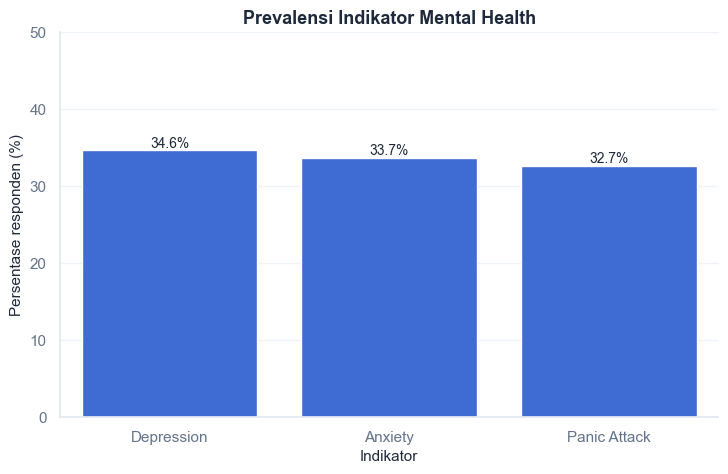

,issue_count,count,percentage
0,0,37,36.630
1,1,36,35.640
2,2,18,17.820
3,3,10,9.900


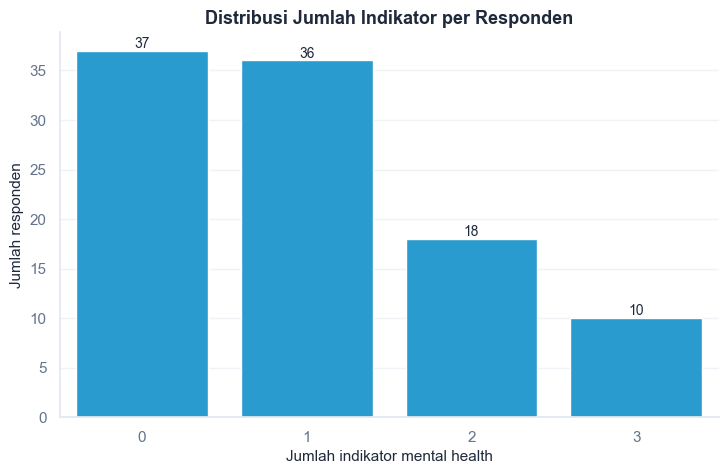

,combination,count,percentage
0,No Indicator,37,36.630
1,Anxiety,13,12.870
2,Panic Attack,13,12.870
3,Depression + Anxiety + Panic Attack,10,9.900
4,Depression,10,9.900
5,Depression + Anxiety,8,7.920
6,Depression + Panic Attack,7,6.930
7,Anxiety + Panic Attack,3,2.970


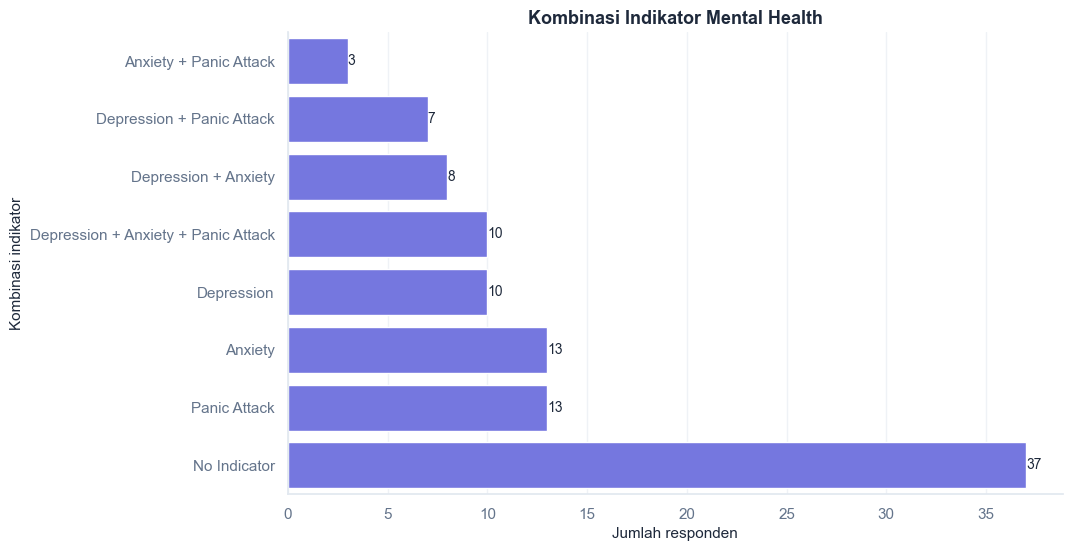

,depression,anxiety,panic_attack,seek_specialist,issue_count
depression,1.000,0.270,0.250,0.350,0.740
anxiety,0.270,1.000,0.080,0.090,0.660
panic_attack,0.250,0.080,1.000,0.180,0.650
seek_specialist,0.350,0.090,0.180,1.000,0.300
issue_count,0.740,0.660,0.650,0.300,1.000


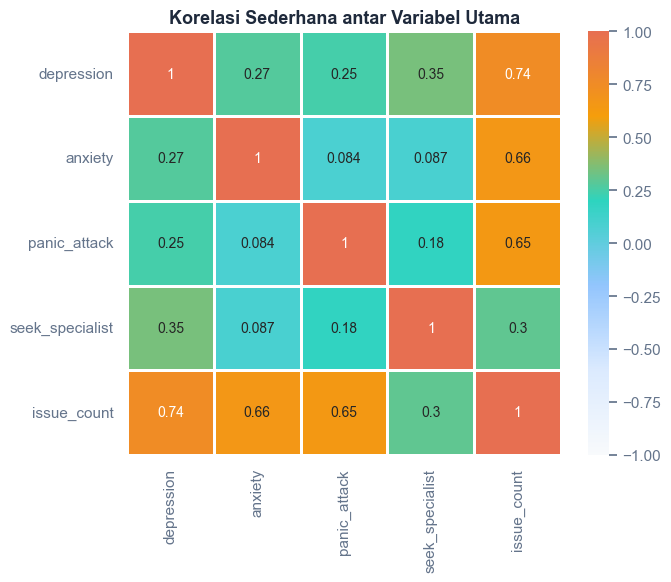

In [6]:
indicator_summary = pd.DataFrame({
    "indicator": ["Depression", "Anxiety", "Panic Attack"],
    "count_yes": [df_clean["depression"].sum(), df_clean["anxiety"].sum(), df_clean["panic_attack"].sum()],
})
indicator_summary["percentage_yes"] = (indicator_summary["count_yes"] / len(df_clean) * 100).round(2)
indicator_summary = indicator_summary.sort_values("percentage_yes", ascending=False)

display(indicator_summary)

fig, ax = plt.subplots(figsize=(8.5, 5))
sns.barplot(data=indicator_summary, x="indicator", y="percentage_yes", color=COLORS["blue"], ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
ax.set_title("Prevalensi Indikator Mental Health")
ax.set_xlabel("Indikator")
ax.set_ylabel("Persentase responden (%)")
ax.set_ylim(0, max(50, indicator_summary["percentage_yes"].max() + 10))
clean_axis(ax)
plt.show()

issue_count_summary = (
    df_clean["issue_count"]
    .value_counts()
    .sort_index()
    .rename_axis("issue_count")
    .reset_index(name="count")
)
issue_count_summary["percentage"] = (issue_count_summary["count"] / len(df_clean) * 100).round(2)

display(issue_count_summary)

fig, ax = plt.subplots(figsize=(8.5, 5))
sns.barplot(data=issue_count_summary, x="issue_count", y="count", color=COLORS["cyan"], ax=ax)
for container in ax.containers:
    ax.bar_label(container)
ax.set_title("Distribusi Jumlah Indikator per Responden")
ax.set_xlabel("Jumlah indikator mental health")
ax.set_ylabel("Jumlah responden")
clean_axis(ax)
plt.show()

def combination_label(row):
    active = []
    if row["depression"] == 1:
        active.append("Depression")
    if row["anxiety"] == 1:
        active.append("Anxiety")
    if row["panic_attack"] == 1:
        active.append("Panic Attack")
    return "No Indicator" if len(active) == 0 else " + ".join(active)

df_clean["indicator_combination"] = df_clean.apply(combination_label, axis=1)

combination_summary = (
    df_clean["indicator_combination"]
    .value_counts()
    .rename_axis("combination")
    .reset_index(name="count")
)
combination_summary["percentage"] = (combination_summary["count"] / len(df_clean) * 100).round(2)

display(combination_summary)

fig, ax = plt.subplots(figsize=(10, 6))
plot_df = combination_summary.sort_values("count", ascending=True)
sns.barplot(data=plot_df, y="combination", x="count", color=COLORS["purple"], ax=ax)
for container in ax.containers:
    ax.bar_label(container)
ax.set_title("Kombinasi Indikator Mental Health")
ax.set_xlabel("Jumlah responden")
ax.set_ylabel("Kombinasi indikator")
clean_axis(ax)
plt.show()

corr_cols = ["depression", "anxiety", "panic_attack", "seek_specialist", "issue_count"]
corr_matrix = df_clean[corr_cols].corr()

display(corr_matrix.round(2))

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr_matrix, annot=True, cmap=mental_cmap, vmin=-1, vmax=1, linewidths=1, linecolor="white", ax=ax)
ax.set_title("Korelasi Sederhana antar Variabel Utama")
plt.show()

## 7. EDA — Support Gap dan Priority Segment

,metric,value
0,Total responden,101.000
1,Memiliki minimal 1 indikator mental health,64.000
2,Tidak memiliki indikator mental health,37.000
3,Silent Struggle: berindikasi tetapi belum mencari bantuan,58.000
4,Reached Support: berindikasi dan sudah mencari bantuan,6.000
5,Silent Struggle Rate among at-risk (%),90.620
6,Support Reach Rate among at-risk (%),9.380


,support_status,count,percentage
0,Stable / No Reported Indicator,37,36.630
1,Silent Struggle,58,57.430
2,Reached Support,6,5.940


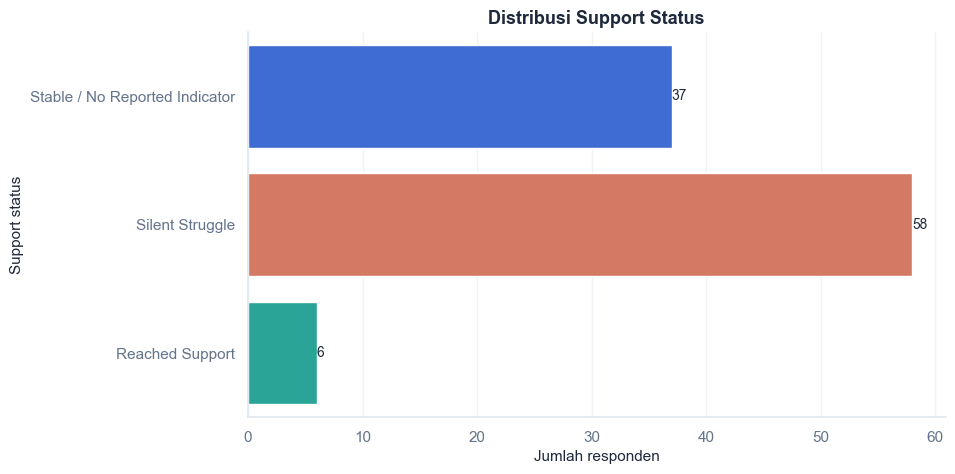

,issue_count,total,seek_support,not_seek_support,seek_support_pct,not_seek_support_pct
0,0,37,0,37,0.000,100.000
1,1,36,0,36,0.000,100.000
2,2,18,5,13,27.780,72.220
3,3,10,1,9,10.000,90.000


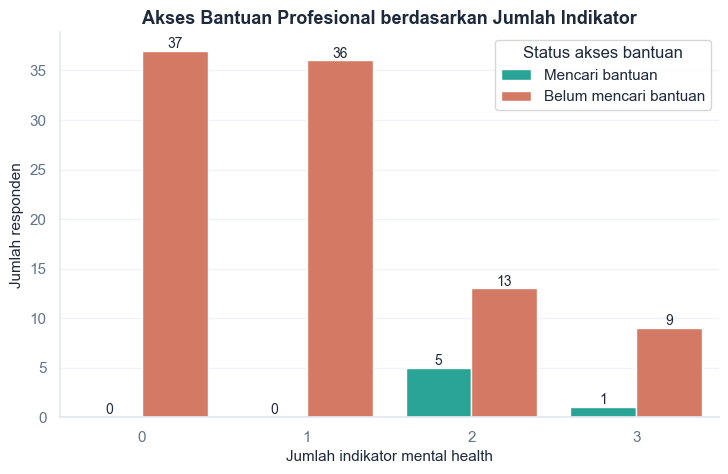

,priority_segment,count,percentage,recommended_action
0,High Priority,22,21.780,"Outreach anonim, check-in berkala, prioritas referral konselor"
1,Medium Priority,36,35.640,"Edukasi, self-assessment, promosi akses layanan"
2,Reached Support,6,5.940,Monitoring kepuasan dan keberlanjutan layanan
3,Stable,37,36.630,Program preventif dan awareness umum


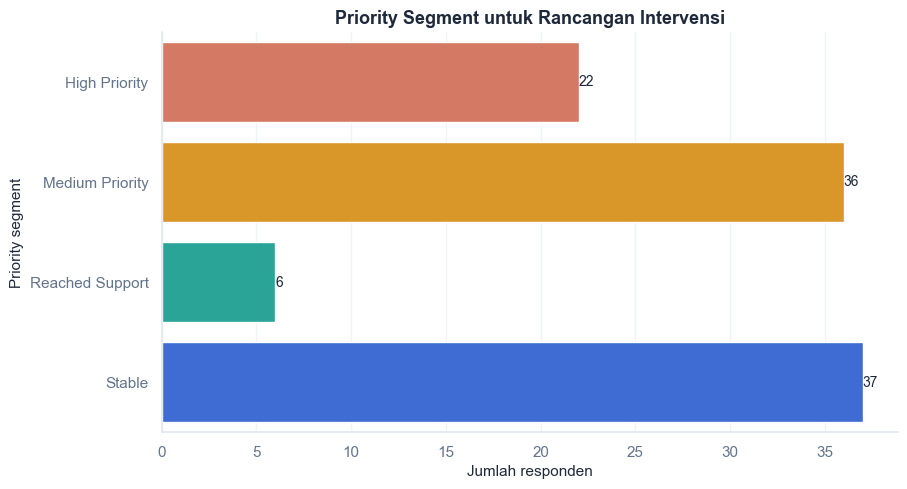


### Interpretasi

Dari **64** responden yang memiliki minimal satu indikator mental health, sebanyak **58 responden** belum mencari bantuan profesional. Dengan kata lain, **90.6%** responden berindikasi masih berada dalam kelompok **Silent Struggle**.

Segmentasi prioritas menghasilkan **22 responden (21.8%)** pada kelompok **High Priority** dan **36 responden (35.6%)** pada kelompok **Medium Priority**.


In [7]:
status_order = ["Stable / No Reported Indicator", "Silent Struggle", "Reached Support"]
status_palette = {
    "Stable / No Reported Indicator": COLORS["blue"],
    "Silent Struggle": COLORS["red"],
    "Reached Support": COLORS["teal"],
}

support_gap_summary = pd.DataFrame({
    "metric": [
        "Total responden",
        "Memiliki minimal 1 indikator mental health",
        "Tidak memiliki indikator mental health",
        "Silent Struggle: berindikasi tetapi belum mencari bantuan",
        "Reached Support: berindikasi dan sudah mencari bantuan",
        "Silent Struggle Rate among at-risk (%)",
        "Support Reach Rate among at-risk (%)",
    ],
    "value": [
        n,
        with_issue,
        without_issue,
        silent_struggle,
        reached_support,
        round(silent_struggle_rate_at_risk, 2),
        round(support_reach_rate, 2),
    ],
})

display(support_gap_summary)

support_status_summary = (
    df_clean["support_status"]
    .value_counts()
    .reindex(status_order, fill_value=0)
    .rename_axis("support_status")
    .reset_index(name="count")
)
support_status_summary["percentage"] = (support_status_summary["count"] / n * 100).round(2)

display(support_status_summary)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=support_status_summary,
    y="support_status",
    x="count",
    hue="support_status",
    hue_order=status_order,
    palette=status_palette,
    order=status_order,
    legend=False,
    ax=ax,
)
for container in ax.containers:
    ax.bar_label(container)
ax.set_title("Distribusi Support Status")
ax.set_xlabel("Jumlah responden")
ax.set_ylabel("Support status")
clean_axis(ax)
plt.show()

support_by_issue_count = (
    df_clean
    .groupby("issue_count", observed=True)
    .agg(total=("issue_count", "size"), seek_support=("seek_specialist", "sum"))
    .reset_index()
)
support_by_issue_count["not_seek_support"] = support_by_issue_count["total"] - support_by_issue_count["seek_support"]
support_by_issue_count["seek_support_pct"] = (support_by_issue_count["seek_support"] / support_by_issue_count["total"] * 100).round(2)
support_by_issue_count["not_seek_support_pct"] = (support_by_issue_count["not_seek_support"] / support_by_issue_count["total"] * 100).round(2)

display(support_by_issue_count)

plot_df = support_by_issue_count.melt(
    id_vars="issue_count",
    value_vars=["seek_support", "not_seek_support"],
    var_name="support_action",
    value_name="count"
)
plot_df["support_action"] = plot_df["support_action"].map({
    "seek_support": "Mencari bantuan",
    "not_seek_support": "Belum mencari bantuan",
})

fig, ax = plt.subplots(figsize=(8.5, 5))
sns.barplot(data=plot_df, x="issue_count", y="count", hue="support_action", palette=[COLORS["teal"], COLORS["red"]], ax=ax)
for container in ax.containers:
    ax.bar_label(container)
ax.set_title("Akses Bantuan Profesional berdasarkan Jumlah Indikator")
ax.set_xlabel("Jumlah indikator mental health")
ax.set_ylabel("Jumlah responden")
ax.legend(title="Status akses bantuan")
clean_axis(ax)
plt.show()

priority_summary = (
    df_clean["priority_segment"]
    .value_counts()
    .reindex(priority_order, fill_value=0)
    .rename_axis("priority_segment")
    .reset_index(name="count")
)
priority_summary["percentage"] = (priority_summary["count"] / n * 100).round(2)

priority_action_map = {
    "High Priority": "Outreach anonim, check-in berkala, prioritas referral konselor",
    "Medium Priority": "Edukasi, self-assessment, promosi akses layanan",
    "Reached Support": "Monitoring kepuasan dan keberlanjutan layanan",
    "Stable": "Program preventif dan awareness umum",
}
priority_summary["recommended_action"] = priority_summary["priority_segment"].astype(str).map(priority_action_map)

display(priority_summary)

priority_palette = {
    "High Priority": COLORS["red"],
    "Medium Priority": COLORS["orange"],
    "Reached Support": COLORS["teal"],
    "Stable": COLORS["blue"],
}

fig, ax = plt.subplots(figsize=(9.5, 5.2))
sns.barplot(
    data=priority_summary,
    y="priority_segment",
    x="count",
    hue="priority_segment",
    hue_order=priority_order,
    order=priority_order,
    palette=priority_palette,
    legend=False,
    ax=ax,
)
for container in ax.containers:
    ax.bar_label(container)
ax.set_title("Priority Segment untuk Rancangan Intervensi")
ax.set_xlabel("Jumlah responden")
ax.set_ylabel("Priority segment")
clean_axis(ax)
plt.show()

high_priority = int((df_clean["priority_segment"] == "High Priority").sum())
medium_priority = int((df_clean["priority_segment"] == "Medium Priority").sum())
high_priority_pct = high_priority / n * 100 if n else 0
medium_priority_pct = medium_priority / n * 100 if n else 0

display(Markdown(f"""
### Interpretasi

Dari **{with_issue}** responden yang memiliki minimal satu indikator mental health, sebanyak **{silent_struggle} responden** belum mencari bantuan profesional. Dengan kata lain, **{silent_struggle_rate_at_risk:.1f}%** responden berindikasi masih berada dalam kelompok **Silent Struggle**.

Segmentasi prioritas menghasilkan **{high_priority} responden ({high_priority_pct:.1f}%)** pada kelompok **High Priority** dan **{medium_priority} responden ({medium_priority_pct:.1f}%)** pada kelompok **Medium Priority**.
"""))

## 8. EDA — Segmentasi Tahun Studi, CGPA, Gender, Umur, dan Course

,year_study,total,with_any_issue,multiple_issue,silent_struggle,reached_support,avg_issue_count,any_issue_pct,silent_struggle_pct,reached_support_pct
0,Year 1,43,25,13,22,3,0.980,58.140,51.160,6.980
1,Year 2,26,19,7,17,2,1.080,73.080,65.380,7.690
2,Year 3,24,18,7,17,1,1.170,75.000,70.830,4.170
3,Year 4,8,2,1,2,0,0.500,25.000,25.000,0.000


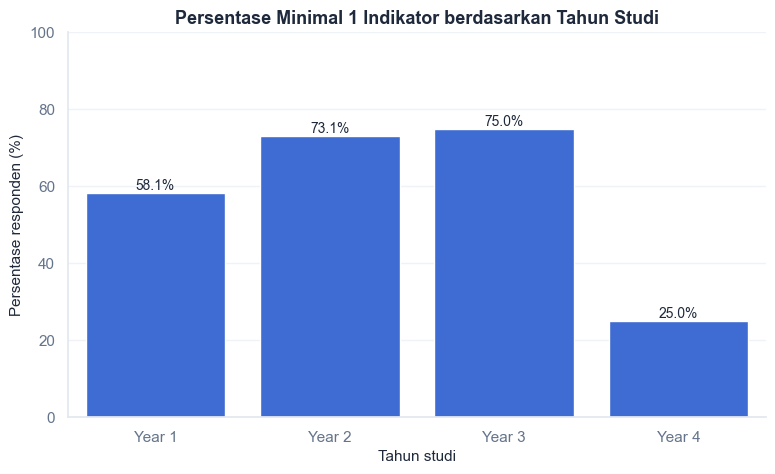

,cgpa,total,with_any_issue,multiple_issue,silent_struggle,reached_support,avg_issue_count,any_issue_pct,silent_struggle_pct,reached_support_pct
0,0 - 1.99,4,1,0,1,0,0.250,25.000,25.000,0.000
1,2.00 - 2.49,2,1,0,1,0,0.500,50.000,50.000,0.000
2,2.50 - 2.99,4,3,3,1,2,1.750,75.000,25.000,50.000
3,3.00 - 3.49,43,28,11,28,0,1.000,65.120,65.120,0.000
4,3.50 - 4.00,48,31,14,27,4,1.040,64.580,56.250,8.330


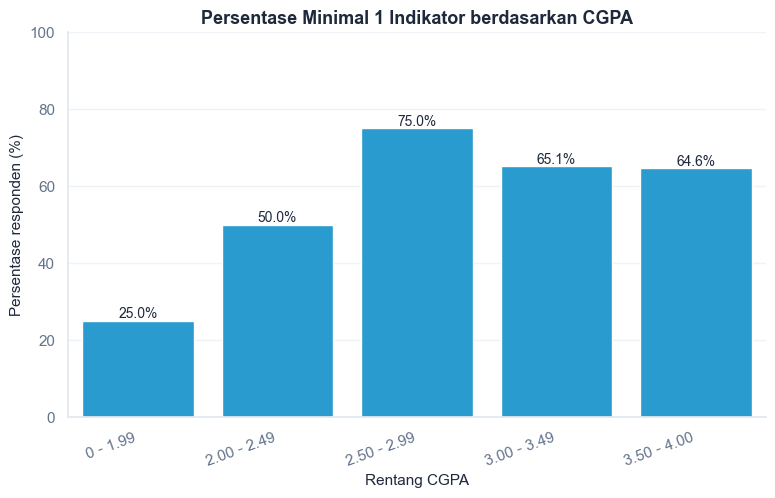

,gender,total,depression_rate,anxiety_rate,panic_attack_rate,any_issue_rate,multiple_issue_rate,silent_struggle_rate,reached_support_rate
0,Female,75,38.670,32.000,33.330,64.000,28.000,57.330,6.670
1,Male,26,23.080,38.460,30.770,61.540,26.920,57.690,3.850


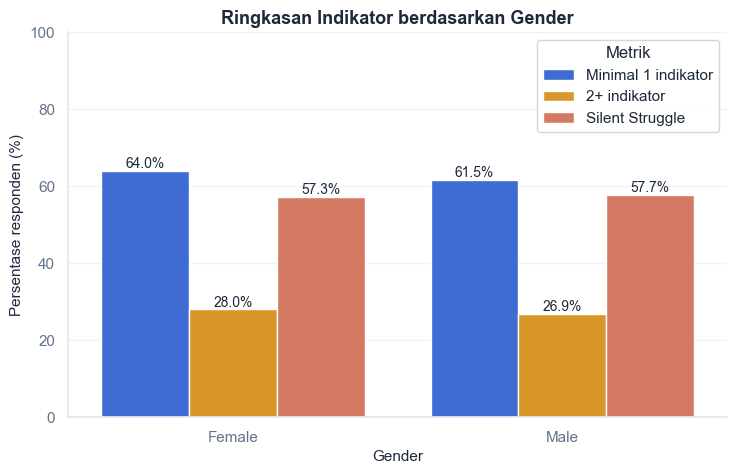

,age_group,total,with_any_issue,multiple_issue,silent_struggle,avg_issue_count,any_issue_pct,silent_struggle_pct
0,<=18,32,22,10,20,1.060,68.750,62.500
1,19-20,28,17,9,16,1.070,60.710,57.140
2,21-22,5,3,0,3,0.600,60.000,60.000
3,23+,36,22,9,19,0.970,61.110,52.780


,course_clean,total
0,Engineering,18
1,Computer Science,18
2,Information Technology,11
3,Koe,6
4,Islamic Education,5
5,Biomedical Science,4
6,Law,3
7,Psychology,3
8,Benl,3
9,Kirkhs,2


,course_clean,total,with_any_issue,silent_struggle,high_priority,avg_issue_count,any_issue_pct,silent_struggle_pct,high_priority_pct
20,Information Technology,11,10,9,3,1.640,90.910,81.820,27.270
25,Koe,6,5,5,2,1.330,83.330,83.330,33.330
14,Engineering,18,12,11,4,0.940,66.670,61.110,22.220
8,Computer Science,18,11,9,2,0.890,61.110,50.000,11.110
22,Islamic Education,5,2,2,1,0.600,40.000,40.000,20.000



### Ringkasan Segmentasi

Pada kelompok dengan jumlah data memadai, **Year 3** memiliki persentase minimal satu indikator tertinggi, yaitu **75.0%** dari **24 responden**.

Untuk CGPA, kelompok **3.00 - 3.49** memiliki persentase minimal satu indikator tertinggi, yaitu **65.1%**.

Hasil segmentasi ini sebaiknya dibaca sebagai sinyal eksploratif, bukan kesimpulan kausal.


In [8]:
def top_segment(summary_df, count_col="total", metric_col="any_issue_pct", min_n=5):
    valid = summary_df[summary_df[count_col] >= min_n].copy()
    if valid.empty:
        valid = summary_df.copy()
    return valid.sort_values(metric_col, ascending=False).iloc[0]

year_summary = (
    df_clean
    .groupby("year_study", observed=True)
    .agg(
        total=("year_study", "size"),
        with_any_issue=("has_any_issue", "sum"),
        multiple_issue=("multiple_issue", "sum"),
        silent_struggle=("support_status", lambda s: (s == "Silent Struggle").sum()),
        reached_support=("support_status", lambda s: (s == "Reached Support").sum()),
        avg_issue_count=("issue_count", "mean"),
    )
    .reset_index()
)
year_summary["any_issue_pct"] = (year_summary["with_any_issue"] / year_summary["total"] * 100).round(2)
year_summary["silent_struggle_pct"] = (year_summary["silent_struggle"] / year_summary["total"] * 100).round(2)
year_summary["reached_support_pct"] = (year_summary["reached_support"] / year_summary["total"] * 100).round(2)
year_summary["avg_issue_count"] = year_summary["avg_issue_count"].round(2)
display(year_summary)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=year_summary, x="year_study", y="any_issue_pct", color=COLORS["blue"], ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
ax.set_title("Persentase Minimal 1 Indikator berdasarkan Tahun Studi")
ax.set_xlabel("Tahun studi")
ax.set_ylabel("Persentase responden (%)")
ax.set_ylim(0, 100)
clean_axis(ax)
plt.show()

cgpa_summary = (
    df_clean
    .groupby("cgpa", observed=True)
    .agg(
        total=("cgpa", "size"),
        with_any_issue=("has_any_issue", "sum"),
        multiple_issue=("multiple_issue", "sum"),
        silent_struggle=("support_status", lambda s: (s == "Silent Struggle").sum()),
        reached_support=("support_status", lambda s: (s == "Reached Support").sum()),
        avg_issue_count=("issue_count", "mean"),
    )
    .reset_index()
)
cgpa_summary["any_issue_pct"] = (cgpa_summary["with_any_issue"] / cgpa_summary["total"] * 100).round(2)
cgpa_summary["silent_struggle_pct"] = (cgpa_summary["silent_struggle"] / cgpa_summary["total"] * 100).round(2)
cgpa_summary["reached_support_pct"] = (cgpa_summary["reached_support"] / cgpa_summary["total"] * 100).round(2)
cgpa_summary["avg_issue_count"] = cgpa_summary["avg_issue_count"].round(2)
display(cgpa_summary)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=cgpa_summary, x="cgpa", y="any_issue_pct", color=COLORS["cyan"], ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
ax.set_title("Persentase Minimal 1 Indikator berdasarkan CGPA")
ax.set_xlabel("Rentang CGPA")
ax.set_ylabel("Persentase responden (%)")
ax.set_ylim(0, 100)
plt.xticks(rotation=20, ha="right")
clean_axis(ax)
plt.show()

gender_summary = (
    df_clean
    .groupby("gender", observed=True)
    .agg(
        total=("gender", "size"),
        depression_rate=("depression", "mean"),
        anxiety_rate=("anxiety", "mean"),
        panic_attack_rate=("panic_attack", "mean"),
        any_issue_rate=("has_any_issue", "mean"),
        multiple_issue_rate=("multiple_issue", "mean"),
        silent_struggle_rate=("support_status", lambda s: (s == "Silent Struggle").mean()),
        reached_support_rate=("support_status", lambda s: (s == "Reached Support").mean()),
    )
    .reset_index()
)
rate_cols = [c for c in gender_summary.columns if c.endswith("_rate")]
gender_summary[rate_cols] = (gender_summary[rate_cols] * 100).round(2)
display(gender_summary)

plot_df = gender_summary.melt(
    id_vars=["gender", "total"],
    value_vars=["any_issue_rate", "multiple_issue_rate", "silent_struggle_rate"],
    var_name="metric",
    value_name="percentage",
)
plot_df["metric"] = plot_df["metric"].map({
    "any_issue_rate": "Minimal 1 indikator",
    "multiple_issue_rate": "2+ indikator",
    "silent_struggle_rate": "Silent Struggle",
})

fig, ax = plt.subplots(figsize=(8.5, 5))
sns.barplot(data=plot_df, x="gender", y="percentage", hue="metric", palette=[COLORS["blue"], COLORS["orange"], COLORS["red"]], ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
ax.set_title("Ringkasan Indikator berdasarkan Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Persentase responden (%)")
ax.set_ylim(0, 100)
ax.legend(title="Metrik")
clean_axis(ax)
plt.show()

age_summary = (
    df_clean
    .groupby("age_group", observed=True)
    .agg(
        total=("age_group", "size"),
        with_any_issue=("has_any_issue", "sum"),
        multiple_issue=("multiple_issue", "sum"),
        silent_struggle=("support_status", lambda s: (s == "Silent Struggle").sum()),
        avg_issue_count=("issue_count", "mean"),
    )
    .reset_index()
)
age_summary["any_issue_pct"] = (age_summary["with_any_issue"] / age_summary["total"] * 100).round(2)
age_summary["silent_struggle_pct"] = (age_summary["silent_struggle"] / age_summary["total"] * 100).round(2)
age_summary["avg_issue_count"] = age_summary["avg_issue_count"].round(2)
display(age_summary)

course_counts = (
    df_clean["course_clean"]
    .value_counts()
    .rename_axis("course_clean")
    .reset_index(name="total")
)
display(course_counts.head(15))

min_n = 5
course_issue_summary = (
    df_clean
    .groupby("course_clean", observed=True)
    .agg(
        total=("course_clean", "size"),
        with_any_issue=("has_any_issue", "sum"),
        silent_struggle=("support_status", lambda s: (s == "Silent Struggle").sum()),
        high_priority=("priority_segment", lambda s: (s == "High Priority").sum()),
        avg_issue_count=("issue_count", "mean"),
    )
    .reset_index()
)
course_issue_summary["any_issue_pct"] = (course_issue_summary["with_any_issue"] / course_issue_summary["total"] * 100).round(2)
course_issue_summary["silent_struggle_pct"] = (course_issue_summary["silent_struggle"] / course_issue_summary["total"] * 100).round(2)
course_issue_summary["high_priority_pct"] = (course_issue_summary["high_priority"] / course_issue_summary["total"] * 100).round(2)
course_issue_summary["avg_issue_count"] = course_issue_summary["avg_issue_count"].round(2)

course_issue_filtered = course_issue_summary[course_issue_summary["total"] >= min_n].sort_values(
    ["any_issue_pct", "total"],
    ascending=[False, False],
)
if course_issue_filtered.empty:
    course_issue_filtered = course_issue_summary.sort_values(["any_issue_pct", "total"], ascending=[False, False])
display(course_issue_filtered)

top_year = top_segment(year_summary)
top_cgpa = top_segment(cgpa_summary)

display(Markdown(f"""
### Ringkasan Segmentasi

Pada kelompok dengan jumlah data memadai, **{top_year["year_study"]}** memiliki persentase minimal satu indikator tertinggi, yaitu **{top_year["any_issue_pct"]:.1f}%** dari **{int(top_year["total"])} responden**.

Untuk CGPA, kelompok **{top_cgpa["cgpa"]}** memiliki persentase minimal satu indikator tertinggi, yaitu **{top_cgpa["any_issue_pct"]:.1f}%**.

Hasil segmentasi ini sebaiknya dibaca sebagai sinyal eksploratif, bukan kesimpulan kausal.
"""))

## 9. Association Test Eksploratif

In [9]:
if HAS_SCIPY:
    def cramers_v(confusion_matrix):
        chi2 = chi2_contingency(confusion_matrix)[0]
        n_obs = confusion_matrix.sum().sum()
        r, k = confusion_matrix.shape
        denom = max(min(k - 1, r - 1), 1)
        return np.sqrt((chi2 / n_obs) / denom) if n_obs else np.nan

    association_targets = ["gender", "year_study", "cgpa", "age_group"]
    assoc_rows = []

    for var in association_targets:
        table = pd.crosstab(df_clean[var], df_clean["has_any_issue"])
        if table.shape[0] > 1 and table.shape[1] > 1:
            chi2, p, dof, expected = chi2_contingency(table)
            assoc_rows.append({
                "variable": var,
                "chi2": round(chi2, 4),
                "p_value": round(p, 4),
                "cramers_v": round(cramers_v(table), 4),
                "interpretation": "exploratory only; not causal",
            })

    association_summary = pd.DataFrame(assoc_rows).sort_values("cramers_v", ascending=False)
    display(association_summary)
else:
    association_summary = pd.DataFrame()
    print("SciPy tidak tersedia, association test dilewati.")

,variable,chi2,p_value,cramers_v,interpretation
1,year_study,8.034,0.045,0.282,exploratory only; not causal
2,cgpa,3.011,0.556,0.173,exploratory only; not causal
3,age_group,0.588,0.899,0.076,exploratory only; not causal
0,gender,0.000,1.000,0.000,exploratory only; not causal


## 10. Export Tabel EDA

In [10]:
df_clean.to_csv(OUTPUT_DIR / "student_mental_health_cleaned.csv", index=False)
indicator_summary.to_csv(OUTPUT_DIR / "indicator_summary.csv", index=False)
issue_count_summary.to_csv(OUTPUT_DIR / "issue_count_summary.csv", index=False)
combination_summary.to_csv(OUTPUT_DIR / "combination_summary.csv", index=False)
support_status_summary.to_csv(OUTPUT_DIR / "support_status_summary.csv", index=False)
support_by_issue_count.to_csv(OUTPUT_DIR / "support_by_issue_count.csv", index=False)
priority_summary.to_csv(OUTPUT_DIR / "priority_summary.csv", index=False)
year_summary.to_csv(OUTPUT_DIR / "year_summary.csv", index=False)
cgpa_summary.to_csv(OUTPUT_DIR / "cgpa_summary.csv", index=False)
gender_summary.to_csv(OUTPUT_DIR / "gender_summary.csv", index=False)
age_summary.to_csv(OUTPUT_DIR / "age_summary.csv", index=False)
course_issue_summary.to_csv(OUTPUT_DIR / "course_issue_summary.csv", index=False)

if not association_summary.empty:
    association_summary.to_csv(OUTPUT_DIR / "association_summary.csv", index=False)

print("Export tabel EDA selesai:")
for file in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", file)

Export tabel EDA selesai:
- d:\Github\nmitggsog-student-mental-health-analysis\prediction_pipeline_outputs\tables\age_summary.csv
- d:\Github\nmitggsog-student-mental-health-analysis\prediction_pipeline_outputs\tables\association_summary.csv
- d:\Github\nmitggsog-student-mental-health-analysis\prediction_pipeline_outputs\tables\cgpa_summary.csv
- d:\Github\nmitggsog-student-mental-health-analysis\prediction_pipeline_outputs\tables\combination_summary.csv
- d:\Github\nmitggsog-student-mental-health-analysis\prediction_pipeline_outputs\tables\course_issue_summary.csv
- d:\Github\nmitggsog-student-mental-health-analysis\prediction_pipeline_outputs\tables\feature_importance_support_status.csv
- d:\Github\nmitggsog-student-mental-health-analysis\prediction_pipeline_outputs\tables\gender_summary.csv
- d:\Github\nmitggsog-student-mental-health-analysis\prediction_pipeline_outputs\tables\indicator_summary.csv
- d:\Github\nmitggsog-student-mental-health-analysis\prediction_pipeline_outputs\tabl

## 11. Visualisasi Presentation-Ready

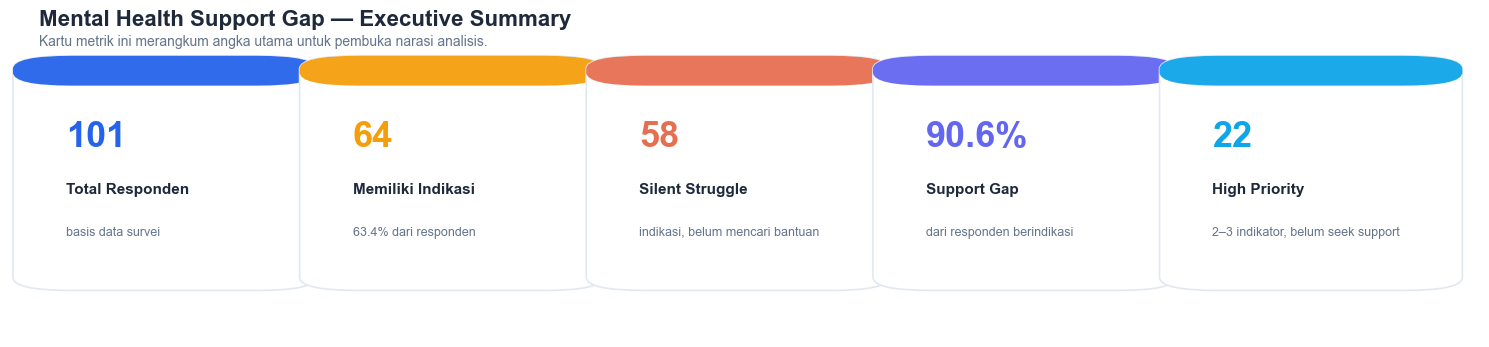

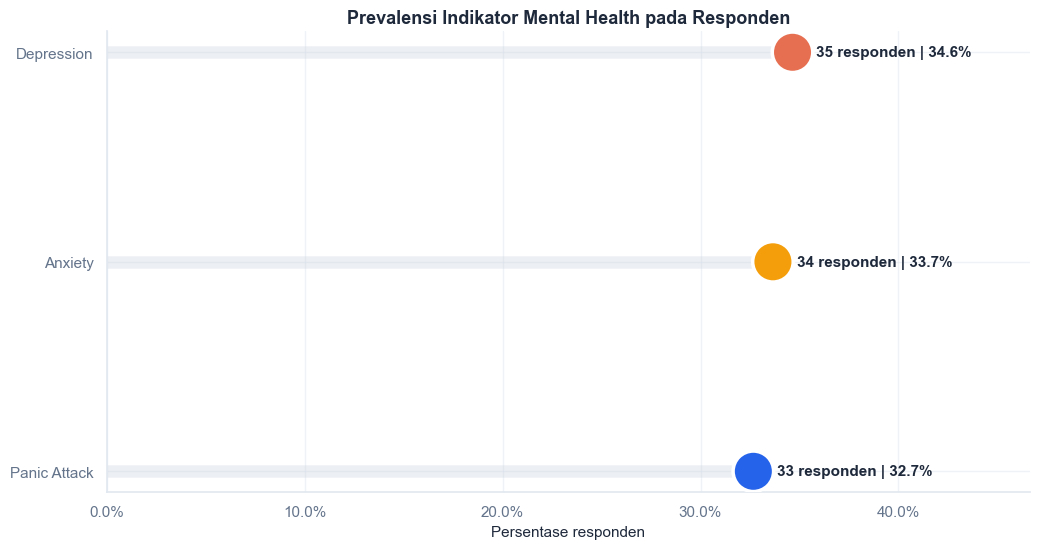

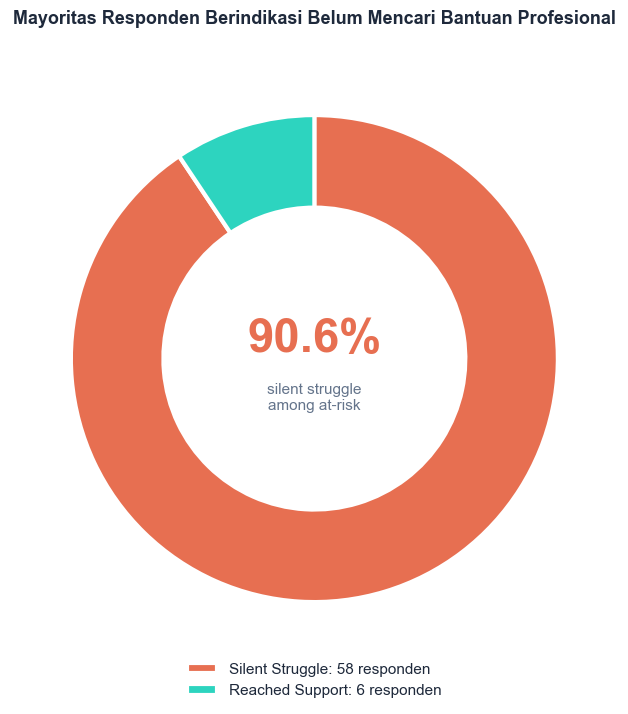

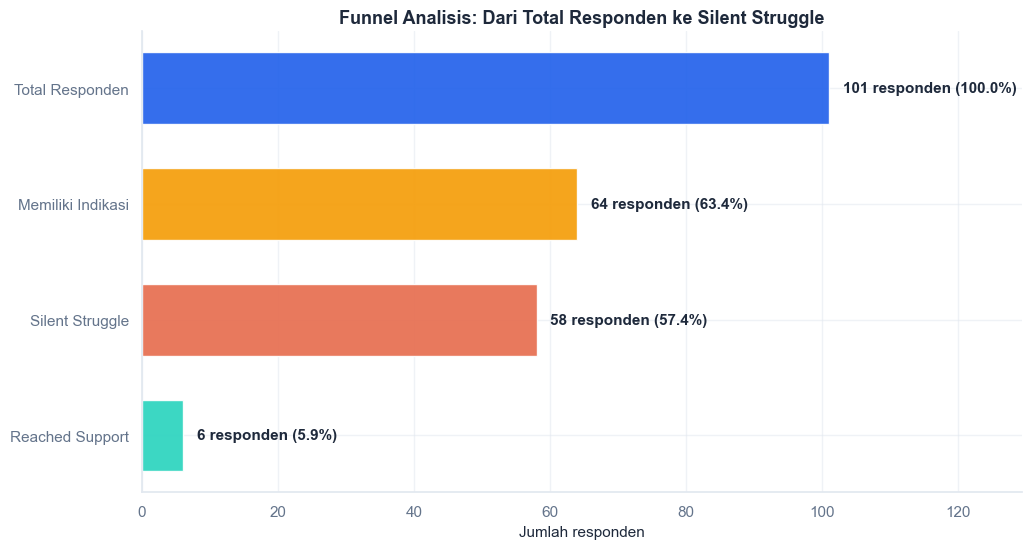

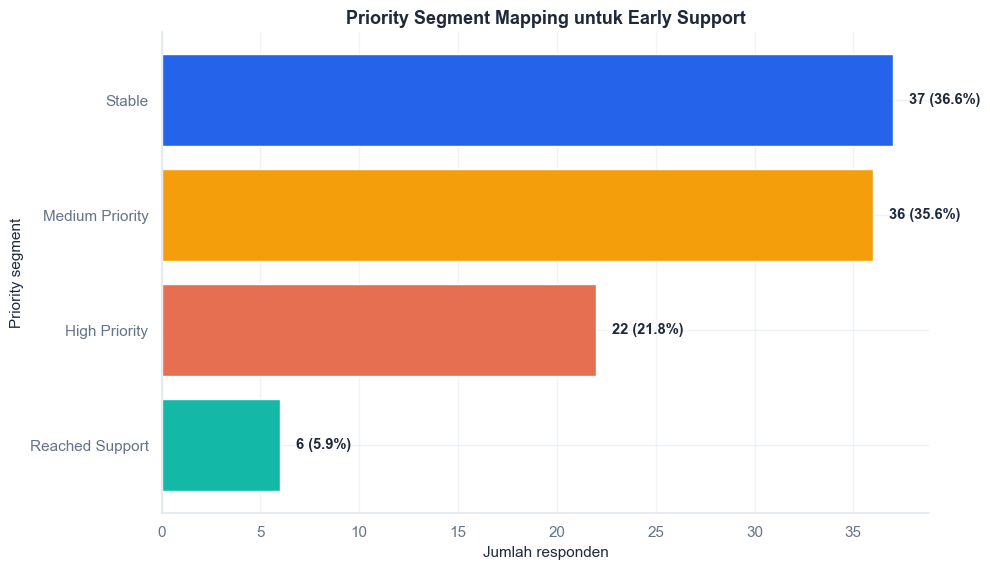

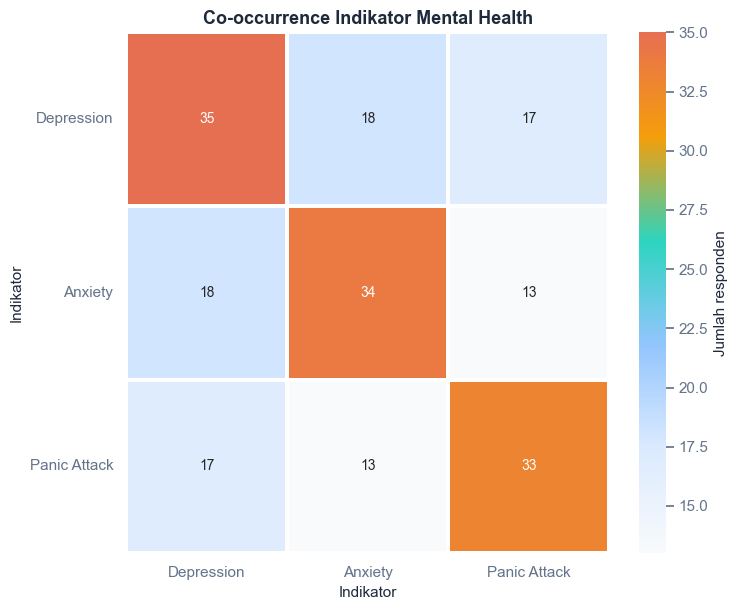

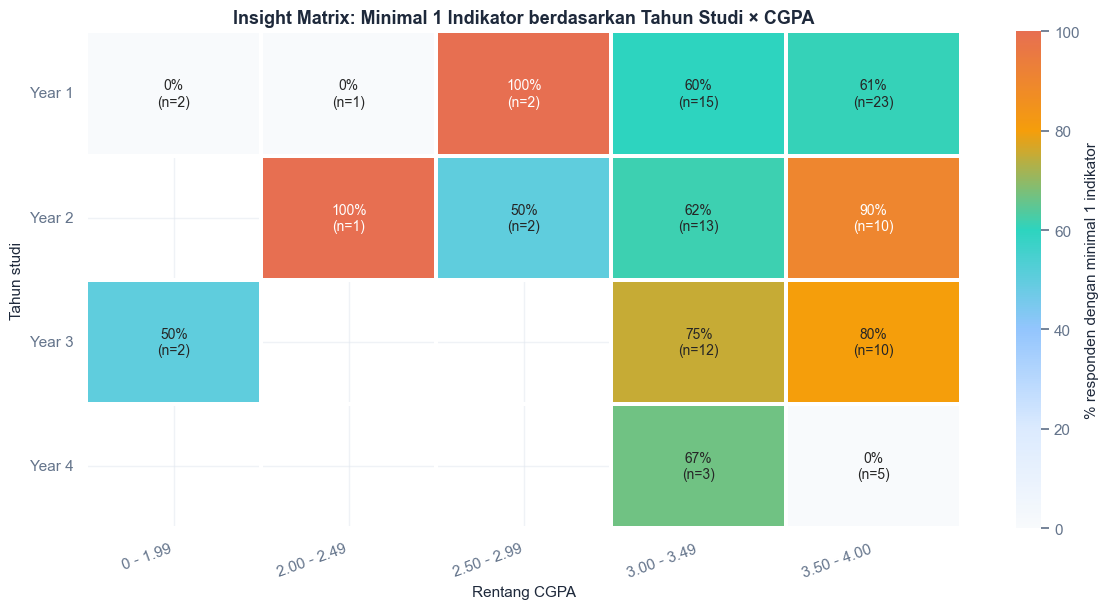

Visualisasi tersimpan di: d:\Github\nmitggsog-student-mental-health-analysis\prediction_pipeline_outputs\visualizations
- 01_kpi_cards_support_gap.png
- 01_label_distribution.png
- 02_lollipop_prevalensi_indikator.png
- 02_model_comparison_weighted_f1.png
- 03_donut_support_gap.png
- 04_funnel_silent_struggle.png
- 05_priority_segment_mapping.png
- 06_heatmap_cooccurrence_indikator.png
- 07_heatmap_tahun_cgpa_any_issue.png
- confusion_matrix_priority_segment.png
- confusion_matrix_support_status.png
- feature_importance_support_status.png


In [11]:
# 1) KPI Cards
kpi_items = [
    ("Total Responden", f"{n}", "basis data survei", COLORS["blue"]),
    ("Memiliki Indikasi", f"{with_issue}", f"{at_risk_rate:.1f}% dari responden", COLORS["orange"]),
    ("Silent Struggle", f"{silent_struggle}", "indikasi, belum mencari bantuan", COLORS["red"]),
    ("Support Gap", f"{silent_struggle_rate_at_risk:.1f}%", "dari responden berindikasi", COLORS["purple"]),
    ("High Priority", f"{high_priority}", "2–3 indikator, belum seek support", COLORS["cyan"]),
]

fig, ax = plt.subplots(figsize=(15, 3.6))
ax.axis("off")

for i, (title, value, subtitle, color) in enumerate(kpi_items):
    x = 0.02 + i * 0.195
    y = 0.16
    w = 0.17
    h = 0.68

    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.018,rounding_size=0.04",
        linewidth=1.2,
        edgecolor="#E2E8F0",
        facecolor="white",
    )
    ax.add_patch(box)

    ax.add_patch(FancyBboxPatch(
        (x, y + h - 0.055), w, 0.055,
        boxstyle="round,pad=0.018,rounding_size=0.04",
        linewidth=0,
        facecolor=color,
        alpha=0.95,
    ))

    ax.text(x + 0.018, y + 0.45, value, fontsize=26, fontweight="bold", color=color, va="center")
    ax.text(x + 0.018, y + 0.29, title, fontsize=11, fontweight="bold", color=COLORS["text"], va="center")
    ax.text(x + 0.018, y + 0.16, subtitle, fontsize=9, color=COLORS["muted"], va="center")

ax.text(0.02, 0.95, "Mental Health Support Gap — Executive Summary", fontsize=16, fontweight="bold")
ax.text(0.02, 0.89, "Kartu metrik ini merangkum angka utama untuk pembuka narasi analisis.", fontsize=10, color=COLORS["muted"])
save_viz("01_kpi_cards_support_gap.png")

# 2) Lollipop prevalensi indikator
indicator_plot = indicator_summary.copy().sort_values("percentage_yes")
indicator_plot["label"] = indicator_plot.apply(
    lambda r: f"{int(r['count_yes'])} responden | {r['percentage_yes']:.1f}%",
    axis=1,
)

fig, ax = plt.subplots(figsize=(10.5, 5.6))
y_pos = np.arange(len(indicator_plot))
colors = [COLORS["blue"], COLORS["orange"], COLORS["red"]]

ax.hlines(
    y=y_pos,
    xmin=0,
    xmax=indicator_plot["percentage_yes"],
    color=COLORS["gray"],
    linewidth=9,
    alpha=0.35,
)
ax.scatter(
    indicator_plot["percentage_yes"],
    y_pos,
    s=850,
    color=colors[:len(indicator_plot)],
    edgecolor="white",
    linewidth=2.5,
    zorder=3,
)

for i, row in enumerate(indicator_plot.itertuples()):
    ax.text(row.percentage_yes + 1.2, i, row.label, va="center", fontsize=11, fontweight="bold")

ax.set_yticks(y_pos)
ax.set_yticklabels(indicator_plot["indicator"])
ax.set_xlim(0, max(45, indicator_plot["percentage_yes"].max() + 12))
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("Persentase responden")
ax.set_title("Prevalensi Indikator Mental Health pada Responden")
clean_axis(ax)
save_viz("02_lollipop_prevalensi_indikator.png")

# 3) Donut support gap
at_risk_counts = pd.Series({
    "Silent Struggle": silent_struggle,
    "Reached Support": reached_support,
})

fig, ax = plt.subplots(figsize=(7.5, 7.2))
wedges, _ = ax.pie(
    at_risk_counts.values,
    startangle=90,
    counterclock=False,
    colors=[COLORS["red"], COLORS["green"]],
    wedgeprops={"width": 0.38, "edgecolor": "white", "linewidth": 3},
)
ax.text(0, 0.08, f"{silent_struggle_rate_at_risk:.1f}%", ha="center", va="center", fontsize=34, fontweight="bold", color=COLORS["red"])
ax.text(0, -0.16, "silent struggle\namong at-risk", ha="center", va="center", fontsize=11, color=COLORS["muted"])
ax.set_title("Mayoritas Responden Berindikasi Belum Mencari Bantuan Profesional", pad=22)
ax.legend(
    wedges,
    [f"{idx}: {val} responden" for idx, val in at_risk_counts.items()],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=1,
    frameon=False,
)
save_viz("03_donut_support_gap.png")

# 4) Funnel
funnel_df = pd.DataFrame({
    "stage": ["Total Responden", "Memiliki Indikasi", "Silent Struggle", "Reached Support"],
    "count": [n, with_issue, silent_struggle, reached_support],
    "color": [COLORS["blue"], COLORS["orange"], COLORS["red"], COLORS["green"]],
})

fig, ax = plt.subplots(figsize=(10.5, 5.6))
y = np.arange(len(funnel_df))
ax.barh(y, funnel_df["count"], color=funnel_df["color"], alpha=0.93, height=0.62)
for i, row in enumerate(funnel_df.itertuples()):
    pct_total = row.count / n * 100 if n else 0
    ax.text(row.count + max(1, n * 0.02), i, f"{row.count} responden ({pct_total:.1f}%)", va="center", fontsize=11, fontweight="bold")
ax.set_yticks(y)
ax.set_yticklabels(funnel_df["stage"])
ax.invert_yaxis()
ax.set_xlim(0, max(funnel_df["count"]) * 1.28 if max(funnel_df["count"]) else 1)
ax.set_xlabel("Jumlah responden")
ax.set_title("Funnel Analisis: Dari Total Responden ke Silent Struggle")
clean_axis(ax)
save_viz("04_funnel_silent_struggle.png")

# 5) Priority segment
priority_plot = priority_summary.copy().sort_values("count", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5.8))
ax.barh(
    priority_plot["priority_segment"].astype(str),
    priority_plot["count"],
    color=[priority_palette[x] for x in priority_plot["priority_segment"].astype(str)],
)
for i, row in enumerate(priority_plot.itertuples()):
    ax.text(row.count + max(0.2, n * 0.008), i, f"{row.count} ({row.percentage:.1f}%)", va="center", fontsize=10.5, fontweight="bold")
ax.set_xlabel("Jumlah responden")
ax.set_ylabel("Priority segment")
ax.set_title("Priority Segment Mapping untuk Early Support")
clean_axis(ax)
save_viz("05_priority_segment_mapping.png")

# 6) Co-occurrence heatmap
issue_names = ["Depression", "Anxiety", "Panic Attack"]
issue_cols = ["depression", "anxiety", "panic_attack"]
co_matrix = pd.DataFrame(index=issue_names, columns=issue_names, dtype=int)

for i, col_i in enumerate(issue_cols):
    for j, col_j in enumerate(issue_cols):
        if i == j:
            co_matrix.iloc[i, j] = int(df_clean[col_i].sum())
        else:
            co_matrix.iloc[i, j] = int(((df_clean[col_i] == 1) & (df_clean[col_j] == 1)).sum())

fig, ax = plt.subplots(figsize=(7.5, 6.2))
sns.heatmap(
    co_matrix,
    annot=True,
    fmt=".0f",
    cmap=mental_cmap,
    linewidths=1.5,
    linecolor="white",
    cbar_kws={"label": "Jumlah responden"},
    ax=ax,
)
ax.set_title("Co-occurrence Indikator Mental Health")
ax.set_xlabel("Indikator")
ax.set_ylabel("Indikator")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
save_viz("06_heatmap_cooccurrence_indikator.png")

# 7) Insight matrix tahun studi x CGPA
risk_matrix = pd.pivot_table(
    df_clean,
    values="has_any_issue",
    index="year_study",
    columns="cgpa",
    aggfunc="mean",
    observed=True,
).mul(100)

count_matrix = pd.pivot_table(
    df_clean,
    values="has_any_issue",
    index="year_study",
    columns="cgpa",
    aggfunc="count",
    observed=True,
)

annot_matrix = risk_matrix.copy().astype(object)
for idx in risk_matrix.index:
    for col in risk_matrix.columns:
        val = risk_matrix.loc[idx, col]
        count = count_matrix.loc[idx, col]
        annot_matrix.loc[idx, col] = "" if pd.isna(val) else f"{val:.0f}%\n(n={int(count)})"

fig, ax = plt.subplots(figsize=(12, 6.2))
sns.heatmap(
    risk_matrix,
    annot=annot_matrix,
    fmt="",
    cmap=mental_cmap,
    vmin=0,
    vmax=100,
    linewidths=1.5,
    linecolor="white",
    cbar_kws={"label": "% responden dengan minimal 1 indikator"},
    ax=ax,
)
ax.set_title("Insight Matrix: Minimal 1 Indikator berdasarkan Tahun Studi × CGPA")
ax.set_xlabel("Rentang CGPA")
ax.set_ylabel("Tahun studi")
plt.xticks(rotation=20, ha="right")
plt.yticks(rotation=0)
save_viz("07_heatmap_tahun_cgpa_any_issue.png")

print("Visualisasi tersimpan di:", VIZ_DIR)
for file in sorted(VIZ_DIR.glob("*.png")):
    print("-", file.name)

# Bagian B — Model Improvement Experiments + Feature Importance

## 12. Setup Data Modeling

In [12]:
FEATURES = ["age", "gender", "course_clean", "year_study", "cgpa", "marital_status"]
NUM_FEATURES = ["age"]
CAT_FEATURES = ["gender", "course_clean", "year_study", "cgpa", "marital_status"]

X = df_clean[FEATURES].copy()
y_multi = df_clean["risk_level"].copy()
y_binary = df_clean["at_risk"].copy()

print("Distribusi target multiclass:")
display(y_multi.value_counts().rename_axis("risk_level").reset_index(name="count"))

print("Distribusi target binary:")
display(y_binary.value_counts().rename_axis("at_risk").reset_index(name="count"))

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), NUM_FEATURES),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ]), CAT_FEATURES),
])

models = {
    "Dummy Most Frequent": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Logistic Regression Balanced": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree Balanced": DecisionTreeClassifier(max_depth=4, min_samples_leaf=3, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest Balanced": RandomForestClassifier(n_estimators=60, max_depth=4, min_samples_leaf=3, class_weight="balanced", random_state=RANDOM_STATE),
    "Extra Trees Balanced": ExtraTreesClassifier(n_estimators=60, max_depth=4, min_samples_leaf=3, class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
}

def choose_n_splits(y, max_splits=5):
    counts = pd.Series(y).value_counts()
    if counts.empty:
        return 0
    return int(min(max_splits, counts.min()))

def evaluate_pipeline_cv(X, y, pipe, experiment_name, model_name):
    n_splits = choose_n_splits(y)
    if n_splits < 2:
        return {
            "experiment": experiment_name,
            "model": model_name,
            "accuracy_mean": np.nan,
            "balanced_accuracy_mean": np.nan,
            "f1_macro_mean": np.nan,
            "f1_weighted_mean": np.nan,
            "n_splits": n_splits,
            "status": "skipped: class count too small for stratified CV",
        }

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    try:
        scores = cross_validate(pipe, X, y, scoring=scoring, cv=cv, n_jobs=1, error_score=np.nan)
        return {
            "experiment": experiment_name,
            "model": model_name,
            "accuracy_mean": np.nanmean(scores["test_accuracy"]),
            "balanced_accuracy_mean": np.nanmean(scores["test_balanced_accuracy"]),
            "f1_macro_mean": np.nanmean(scores["test_f1_macro"]),
            "f1_weighted_mean": np.nanmean(scores["test_f1_weighted"]),
            "n_splits": n_splits,
            "status": "ok",
        }
    except Exception as e:
        return {
            "experiment": experiment_name,
            "model": model_name,
            "accuracy_mean": np.nan,
            "balanced_accuracy_mean": np.nan,
            "f1_macro_mean": np.nan,
            "f1_weighted_mean": np.nan,
            "n_splits": n_splits,
            "status": f"failed: {type(e).__name__}: {e}",
        }

def evaluate_models(X, y, experiment_name, model_dict):
    rows = []
    for model_name, model in model_dict.items():
        pipe = Pipeline([
            ("preprocess", deepcopy(preprocessor)),
            ("model", clone(model)),
        ])
        rows.append(evaluate_pipeline_cv(X, y, pipe, experiment_name, model_name))

    return (
        pd.DataFrame(rows)
        .sort_values(["f1_macro_mean", "balanced_accuracy_mean"], ascending=False, na_position="last")
        .reset_index(drop=True)
    )

Distribusi target multiclass:


,risk_level,count
0,Low Risk,37
1,Medium Risk,36
2,High Risk,28


Distribusi target binary:


,at_risk,count
0,At Risk,64
1,No Risk,37


## 13. Eksperimen 1 — Multiclass Risk Level

In [13]:
result_multi = evaluate_models(X, y_multi, "Multiclass Risk Level", models)
display(result_multi.round(3))

,experiment,model,accuracy_mean,balanced_accuracy_mean,f1_macro_mean,f1_weighted_mean,n_splits,status
0,Multiclass Risk Level,Extra Trees Balanced,0.475,0.472,0.460,0.457,5,ok
1,Multiclass Risk Level,Logistic Regression,0.435,0.432,0.421,0.422,5,ok
2,Multiclass Risk Level,Random Forest Balanced,0.416,0.412,0.405,0.400,5,ok
3,Multiclass Risk Level,Logistic Regression Balanced,0.416,0.414,0.403,0.403,5,ok
4,Multiclass Risk Level,Gradient Boosting,0.386,0.386,0.376,0.376,5,ok
5,Multiclass Risk Level,Decision Tree Balanced,0.336,0.338,0.270,0.269,5,ok
6,Multiclass Risk Level,Dummy Most Frequent,0.366,0.333,0.179,0.197,5,ok


## 14. Eksperimen 2 — Binary At Risk

In [14]:
result_binary = evaluate_models(X, y_binary, "Binary At Risk", models)
display(result_binary.round(3))

,experiment,model,accuracy_mean,balanced_accuracy_mean,f1_macro_mean,f1_weighted_mean,n_splits,status
0,Binary At Risk,Gradient Boosting,0.693,0.627,0.618,0.662,5,ok
1,Binary At Risk,Logistic Regression,0.703,0.620,0.606,0.660,5,ok
2,Binary At Risk,Logistic Regression Balanced,0.614,0.608,0.589,0.607,5,ok
3,Binary At Risk,Decision Tree Balanced,0.573,0.610,0.570,0.572,5,ok
4,Binary At Risk,Random Forest Balanced,0.554,0.562,0.541,0.556,5,ok
5,Binary At Risk,Extra Trees Balanced,0.554,0.585,0.536,0.540,5,ok
6,Binary At Risk,Dummy Most Frequent,0.634,0.500,0.388,0.492,5,ok


## 15. Eksperimen 3 — Oversampling untuk Binary Target

In [15]:
oversampling_models = {}

if HAS_IMBLEARN:
    oversampling_models["LogReg Balanced + ROS"] = ImbPipeline([
        ("preprocess", deepcopy(preprocessor)),
        ("oversample", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ])

    oversampling_models["RF + ROS"] = ImbPipeline([
        ("preprocess", deepcopy(preprocessor)),
        ("oversample", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", RandomForestClassifier(n_estimators=60, max_depth=4, min_samples_leaf=3, random_state=RANDOM_STATE)),
    ])

    min_class_count = y_binary.value_counts().min()
    if min_class_count >= 6:
        k_neighbors = min(3, int(min_class_count) - 1)
        oversampling_models["LogReg Balanced + SMOTE"] = ImbPipeline([
            ("preprocess", deepcopy(preprocessor)),
            ("oversample", SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors)),
            ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
        ])

if oversampling_models:
    rows = []
    for model_name, pipe in oversampling_models.items():
        rows.append(evaluate_pipeline_cv(X, y_binary, pipe, "Binary At Risk with Oversampling", model_name))
    result_oversampling = (
        pd.DataFrame(rows)
        .sort_values(["f1_macro_mean", "balanced_accuracy_mean"], ascending=False, na_position="last")
        .reset_index(drop=True)
    )
else:
    result_oversampling = pd.DataFrame(columns=[
        "experiment", "model", "accuracy_mean", "balanced_accuracy_mean",
        "f1_macro_mean", "f1_weighted_mean", "n_splits", "status"
    ])
    print("Oversampling dilewati karena imbalanced-learn tidak tersedia atau data tidak memenuhi syarat.")

display(result_oversampling.round(3))

,experiment,model,accuracy_mean,balanced_accuracy_mean,f1_macro_mean,f1_weighted_mean,n_splits,status
0,Binary At Risk with Oversampling,LogReg Balanced + ROS,0.662,0.635,0.633,0.659,5,ok
1,Binary At Risk with Oversampling,LogReg Balanced + SMOTE,0.604,0.577,0.570,0.600,5,ok
2,Binary At Risk with Oversampling,RF + ROS,0.564,0.582,0.544,0.554,5,ok


## 16. Leakage Demo — Skor Tinggi tapi Tidak Valid

In [16]:
LEAK_FEATURES = FEATURES + ["depression", "anxiety", "panic_attack"]
LEAK_NUM_FEATURES = NUM_FEATURES + ["depression", "anxiety", "panic_attack"]
LEAK_CAT_FEATURES = CAT_FEATURES

X_leak = df_clean[LEAK_FEATURES].copy()

leak_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), LEAK_NUM_FEATURES),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ]), LEAK_CAT_FEATURES),
])

leak_models = {
    "LogReg Leakage": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "RF Leakage": RandomForestClassifier(n_estimators=60, max_depth=4, min_samples_leaf=3, random_state=RANDOM_STATE),
}

leak_rows = []
for model_name, model in leak_models.items():
    pipe = Pipeline([
        ("preprocess", deepcopy(leak_preprocessor)),
        ("model", clone(model)),
    ])
    leak_rows.append(evaluate_pipeline_cv(X_leak, y_multi, pipe, "Leakage Demo - Invalid", model_name))

result_leakage = (
    pd.DataFrame(leak_rows)
    .sort_values(["f1_macro_mean", "balanced_accuracy_mean"], ascending=False, na_position="last")
    .reset_index(drop=True)
)

display(result_leakage.round(3))

,experiment,model,accuracy_mean,balanced_accuracy_mean,f1_macro_mean,f1_weighted_mean,n_splits,status
0,Leakage Demo - Invalid,LogReg Leakage,0.990,0.987,0.988,0.990,5,ok
1,Leakage Demo - Invalid,RF Leakage,0.832,0.819,0.811,0.817,5,ok


## 17. Holdout Report Model Terbaik

In [17]:
def best_valid_row(result_df):
    valid = result_df[result_df["status"].eq("ok")].copy()
    valid = valid.dropna(subset=["f1_macro_mean"])
    if valid.empty:
        return None
    return valid.sort_values(["f1_macro_mean", "balanced_accuracy_mean"], ascending=False).iloc[0]

def get_pipeline_from_row(row):
    experiment = row["experiment"]
    model_name = row["model"]

    if experiment == "Binary At Risk with Oversampling" and model_name in oversampling_models:
        return clone(oversampling_models[model_name])

    if model_name in models:
        return Pipeline([
            ("preprocess", deepcopy(preprocessor)),
            ("model", clone(models[model_name])),
        ])

    raise ValueError(f"Model tidak ditemukan: {model_name}")

def holdout_report(X, y, row, title):
    if row is None:
        print(f"{title}: tidak ada model valid.")
        return None

    if pd.Series(y).value_counts().min() < 2:
        print(f"{title}: data terlalu kecil untuk stratified holdout.")
        return None

    pipe = get_pipeline_from_row(row)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    print(title)
    print("Model:", row["model"])
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
    print("Balanced Accuracy:", round(balanced_accuracy_score(y_test, y_pred), 3))
    print("F1 Macro:", round(f1_score(y_test, y_pred, average="macro"), 3))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=3))

    return {
        "pipeline": pipe,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred,
    }

best_multi_row = best_valid_row(result_multi)
best_binary_source = pd.concat([result_binary, result_oversampling], ignore_index=True)
best_binary_row = best_valid_row(best_binary_source)

multi_holdout = holdout_report(X, y_multi, best_multi_row, "Multiclass Holdout")
print("-" * 70)
binary_holdout = holdout_report(X, y_binary, best_binary_row, "Binary Holdout")

Multiclass Holdout
Model: Extra Trees Balanced
Accuracy: 0.538
Balanced Accuracy: 0.517
F1 Macro: 0.499

Classification Report:
              precision    recall  f1-score   support

   High Risk      0.750     0.429     0.545         7
    Low Risk      0.500     0.900     0.643        10
 Medium Risk      0.500     0.222     0.308         9

    accuracy                          0.538        26
   macro avg      0.583     0.517     0.499        26
weighted avg      0.567     0.538     0.501        26

----------------------------------------------------------------------
Binary Holdout
Model: LogReg Balanced + ROS
Accuracy: 0.5
Balanced Accuracy: 0.5
F1 Macro: 0.493

Classification Report:
              precision    recall  f1-score   support

     At Risk      0.615     0.500     0.552        16
     No Risk      0.385     0.500     0.435        10

    accuracy                          0.500        26
   macro avg      0.500     0.500     0.493        26
weighted avg      0.527    

## 18. Ringkasan Eksperimen Valid

In [18]:
all_valid_results = pd.concat([result_multi, result_binary, result_oversampling], ignore_index=True)
all_valid_results_sorted = (
    all_valid_results
    .sort_values(["f1_macro_mean", "balanced_accuracy_mean"], ascending=False, na_position="last")
    .reset_index(drop=True)
)

display(all_valid_results_sorted.round(3))

,experiment,model,accuracy_mean,balanced_accuracy_mean,f1_macro_mean,f1_weighted_mean,n_splits,status
0,Binary At Risk with Oversampling,LogReg Balanced + ROS,0.662,0.635,0.633,0.659,5,ok
1,Binary At Risk,Gradient Boosting,0.693,0.627,0.618,0.662,5,ok
2,Binary At Risk,Logistic Regression,0.703,0.620,0.606,0.660,5,ok
3,Binary At Risk,Logistic Regression Balanced,0.614,0.608,0.589,0.607,5,ok
4,Binary At Risk with Oversampling,LogReg Balanced + SMOTE,0.604,0.577,0.570,0.600,5,ok
5,Binary At Risk,Decision Tree Balanced,0.573,0.610,0.570,0.572,5,ok
6,Binary At Risk with Oversampling,RF + ROS,0.564,0.582,0.544,0.554,5,ok
7,Binary At Risk,Random Forest Balanced,0.554,0.562,0.541,0.556,5,ok
8,Binary At Risk,Extra Trees Balanced,0.554,0.585,0.536,0.540,5,ok
9,Multiclass Risk Level,Extra Trees Balanced,0.475,0.472,0.460,0.457,5,ok


## 19. Feature Importance Model Valid

,experiment,model,encoded_feature,importance,importance_type,base_feature,importance_norm
0,Binary At Risk with Oversampling,LogReg Balanced + ROS,age,0.146,absolute_coefficient,age,0.006
1,Binary At Risk with Oversampling,LogReg Balanced + ROS,gender_Female,0.016,absolute_coefficient,gender,0.001
2,Binary At Risk with Oversampling,LogReg Balanced + ROS,gender_Male,0.015,absolute_coefficient,gender,0.001
3,Binary At Risk with Oversampling,LogReg Balanced + ROS,course_clean_Accounting,0.437,absolute_coefficient,course_clean,0.019
4,Binary At Risk with Oversampling,LogReg Balanced + ROS,course_clean_Ala,0.205,absolute_coefficient,course_clean,0.009
5,Binary At Risk with Oversampling,LogReg Balanced + ROS,course_clean_Banking Studies,0.365,absolute_coefficient,course_clean,0.016
6,Binary At Risk with Oversampling,LogReg Balanced + ROS,course_clean_Benl,0.212,absolute_coefficient,course_clean,0.009
7,Binary At Risk with Oversampling,LogReg Balanced + ROS,course_clean_Biomedical Science,1.129,absolute_coefficient,course_clean,0.049
8,Binary At Risk with Oversampling,LogReg Balanced + ROS,course_clean_Biotechnology,0.501,absolute_coefficient,course_clean,0.022
9,Binary At Risk with Oversampling,LogReg Balanced + ROS,course_clean_Business Administration,0.457,absolute_coefficient,course_clean,0.020


,base_feature,mean_importance,max_importance,appeared_in_models
4,marital_status,0.135,0.498,9
5,year_study,0.035,0.139,9
0,age,0.033,0.092,9
1,cgpa,0.015,0.051,9
2,course_clean,0.013,0.180,9
3,gender,0.007,0.025,9


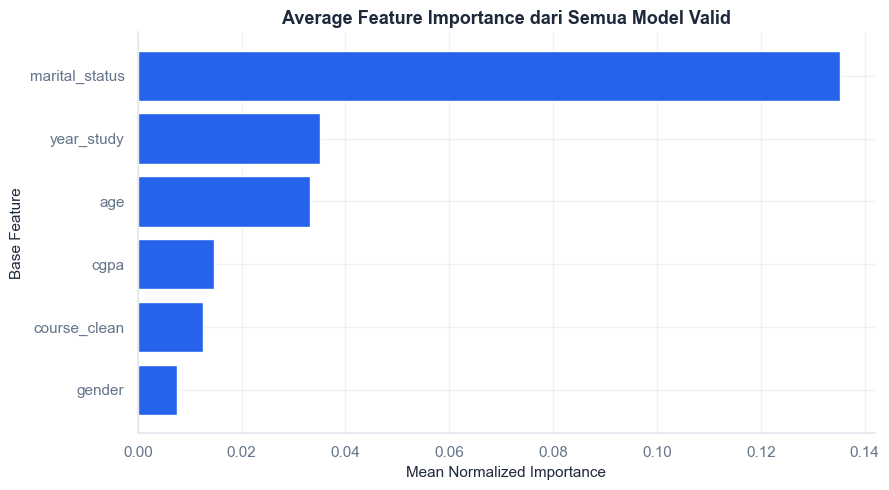

In [19]:
def get_feature_names_from_pipeline(fitted_pipe, cat_features=CAT_FEATURES, num_features=NUM_FEATURES):
    pre = fitted_pipe.named_steps["preprocess"]
    feature_names = []

    if "num" in pre.named_transformers_:
        feature_names.extend(num_features)

    if "cat" in pre.named_transformers_:
        cat_pipeline = pre.named_transformers_["cat"]
        encoder = cat_pipeline.named_steps["onehot"]
        cat_names = encoder.get_feature_names_out(cat_features)
        feature_names.extend(cat_names)

    return list(feature_names)

def map_base_feature(encoded_feature_name, base_features):
    for base in sorted(base_features, key=len, reverse=True):
        if encoded_feature_name == base or encoded_feature_name.startswith(base + "_"):
            return base
    return encoded_feature_name

def extract_builtin_importance(fitted_pipe, base_features, experiment_name, model_name):
    model = fitted_pipe.named_steps["model"]
    feature_names = get_feature_names_from_pipeline(fitted_pipe)

    if hasattr(model, "feature_importances_"):
        values = np.asarray(model.feature_importances_)
        importance_type = "tree_feature_importance"
    elif hasattr(model, "coef_"):
        coef = np.asarray(model.coef_)
        values = np.abs(coef) if coef.ndim == 1 else np.mean(np.abs(coef), axis=0)
        importance_type = "absolute_coefficient"
    else:
        return pd.DataFrame()

    n_features = min(len(feature_names), len(values))
    temp = pd.DataFrame({
        "experiment": experiment_name,
        "model": model_name,
        "encoded_feature": feature_names[:n_features],
        "importance": values[:n_features],
        "importance_type": importance_type,
    })

    temp["base_feature"] = temp["encoded_feature"].apply(lambda x: map_base_feature(x, base_features))
    total_importance = temp["importance"].sum()
    temp["importance_norm"] = temp["importance"] / total_importance if total_importance else 0
    return temp

valid_feature_importance_frames = []

valid_rows = all_valid_results_sorted[
    (all_valid_results_sorted["status"] == "ok") &
    (~all_valid_results_sorted["model"].str.contains("Dummy", case=False, regex=False))
].copy()

for _, row in valid_rows.iterrows():
    try:
        pipe = get_pipeline_from_row(row)
        target = y_binary if "Binary" in row["experiment"] else y_multi
        pipe.fit(X, target)

        temp = extract_builtin_importance(pipe, FEATURES, row["experiment"], row["model"])
        if not temp.empty:
            valid_feature_importance_frames.append(temp)
    except Exception as e:
        print(f"Feature importance dilewati untuk {row['model']}: {e}")

if valid_feature_importance_frames:
    valid_feature_importance_summary = pd.concat(valid_feature_importance_frames, ignore_index=True)
else:
    valid_feature_importance_summary = pd.DataFrame(columns=[
        "experiment", "model", "encoded_feature", "importance",
        "importance_type", "base_feature", "importance_norm"
    ])

display(valid_feature_importance_summary.head(20))

if not valid_feature_importance_summary.empty:
    overall_valid_importance = (
        valid_feature_importance_summary
        .groupby("base_feature", as_index=False)
        .agg(
            mean_importance=("importance_norm", "mean"),
            max_importance=("importance_norm", "max"),
            appeared_in_models=("model", "nunique"),
        )
        .sort_values("mean_importance", ascending=False)
    )
else:
    overall_valid_importance = pd.DataFrame(columns=["base_feature", "mean_importance", "max_importance", "appeared_in_models"])

display(overall_valid_importance.round(4))

if not overall_valid_importance.empty:
    fig, ax = plt.subplots(figsize=(9, 5))
    plot_df = overall_valid_importance.sort_values("mean_importance", ascending=True)
    ax.barh(plot_df["base_feature"], plot_df["mean_importance"], color=COLORS["blue"])
    ax.set_title("Average Feature Importance dari Semua Model Valid")
    ax.set_xlabel("Mean Normalized Importance")
    ax.set_ylabel("Base Feature")
    clean_axis(ax)
    save_viz("08_average_valid_feature_importance.png")

## 20. Permutation Importance Model Binary Terbaik

,feature,importance_mean,importance_std
2,course_clean,0.083,0.056
4,cgpa,0.022,0.025
0,age,0.020,0.033
5,marital_status,-0.001,0.039
1,gender,-0.037,0.038
3,year_study,-0.115,0.096


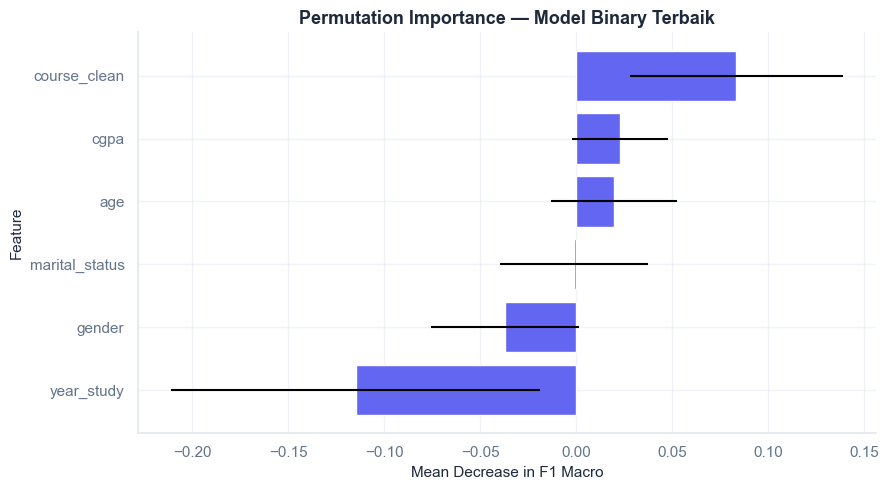

In [20]:
if binary_holdout is not None:
    best_binary_pipe = binary_holdout["pipeline"]
    X_test = binary_holdout["X_test"]
    y_test = binary_holdout["y_test"]

    perm = permutation_importance(
        best_binary_pipe,
        X_test,
        y_test,
        scoring="f1_macro",
        n_repeats=30,
        random_state=RANDOM_STATE,
    )

    permutation_importance_df = pd.DataFrame({
        "feature": FEATURES,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance_mean", ascending=False)
else:
    permutation_importance_df = pd.DataFrame(columns=["feature", "importance_mean", "importance_std"])

display(permutation_importance_df.round(4))

if not permutation_importance_df.empty:
    fig, ax = plt.subplots(figsize=(9, 5))
    plot_df = permutation_importance_df.sort_values("importance_mean", ascending=True)
    ax.barh(plot_df["feature"], plot_df["importance_mean"], xerr=plot_df["importance_std"], color=COLORS["purple"])
    ax.set_title("Permutation Importance — Model Binary Terbaik")
    ax.set_xlabel("Mean Decrease in F1 Macro")
    ax.set_ylabel("Feature")
    clean_axis(ax)
    save_viz("09_best_binary_permutation_importance.png")

## 21. Feature Importance Leakage Demo

,base_feature,mean_importance
4,depression,0.190
1,anxiety,0.176
7,panic_attack,0.142
6,marital_status,0.045
0,age,0.028
8,year_study,0.021
5,gender,0.010
2,cgpa,0.010
3,course_clean,0.006


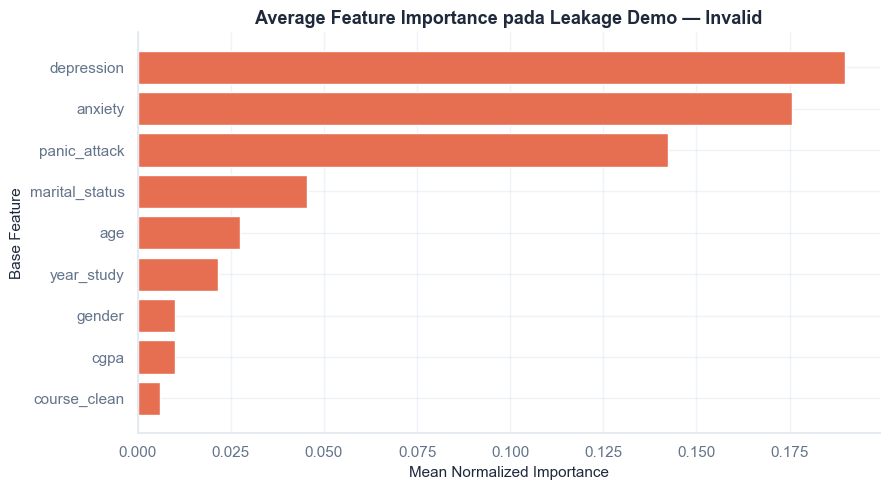

In [21]:
def get_leak_feature_names_from_pipeline(fitted_pipe):
    pre = fitted_pipe.named_steps["preprocess"]
    feature_names = []

    if "num" in pre.named_transformers_:
        feature_names.extend(LEAK_NUM_FEATURES)

    if "cat" in pre.named_transformers_:
        cat_pipeline = pre.named_transformers_["cat"]
        encoder = cat_pipeline.named_steps["onehot"]
        cat_names = encoder.get_feature_names_out(LEAK_CAT_FEATURES)
        feature_names.extend(cat_names)

    return list(feature_names)

def extract_leak_importance(fitted_pipe, base_features, experiment_name, model_name):
    model = fitted_pipe.named_steps["model"]
    feature_names = get_leak_feature_names_from_pipeline(fitted_pipe)

    if hasattr(model, "feature_importances_"):
        values = np.asarray(model.feature_importances_)
        importance_type = "tree_feature_importance"
    elif hasattr(model, "coef_"):
        coef = np.asarray(model.coef_)
        values = np.abs(coef) if coef.ndim == 1 else np.mean(np.abs(coef), axis=0)
        importance_type = "absolute_coefficient"
    else:
        return pd.DataFrame()

    n_features = min(len(feature_names), len(values))
    temp = pd.DataFrame({
        "experiment": experiment_name,
        "model": model_name,
        "encoded_feature": feature_names[:n_features],
        "importance": values[:n_features],
        "importance_type": importance_type,
    })

    temp["base_feature"] = temp["encoded_feature"].apply(lambda x: map_base_feature(x, base_features))
    total_importance = temp["importance"].sum()
    temp["importance_norm"] = temp["importance"] / total_importance if total_importance else 0
    return temp

leak_feature_importance_frames = []

for model_name, model in leak_models.items():
    pipe = Pipeline([
        ("preprocess", deepcopy(leak_preprocessor)),
        ("model", clone(model)),
    ])

    try:
        pipe.fit(X_leak, y_multi)
        temp = extract_leak_importance(pipe, LEAK_FEATURES, "Leakage Demo - Invalid", model_name)
        if not temp.empty:
            leak_feature_importance_frames.append(temp)
    except Exception as e:
        print(f"Leakage importance dilewati untuk {model_name}: {e}")

if leak_feature_importance_frames:
    leak_feature_importance_summary = pd.concat(leak_feature_importance_frames, ignore_index=True)
else:
    leak_feature_importance_summary = pd.DataFrame(columns=[
        "experiment", "model", "encoded_feature", "importance",
        "importance_type", "base_feature", "importance_norm"
    ])

if not leak_feature_importance_summary.empty:
    overall_leak_importance = (
        leak_feature_importance_summary
        .groupby("base_feature", as_index=False)
        .agg(mean_importance=("importance_norm", "mean"))
        .sort_values("mean_importance", ascending=False)
    )
else:
    overall_leak_importance = pd.DataFrame(columns=["base_feature", "mean_importance"])

display(overall_leak_importance.round(4))

if not overall_leak_importance.empty:
    fig, ax = plt.subplots(figsize=(9, 5))
    plot_df = overall_leak_importance.sort_values("mean_importance", ascending=True)
    ax.barh(plot_df["base_feature"], plot_df["mean_importance"], color=COLORS["red"])
    ax.set_title("Average Feature Importance pada Leakage Demo — Invalid")
    ax.set_xlabel("Mean Normalized Importance")
    ax.set_ylabel("Base Feature")
    clean_axis(ax)
    save_viz("10_average_leakage_feature_importance.png")

## 22. SHAP Value — Interpretasi Model Binary Terbaik

Bagian ini menambahkan interpretasi **SHAP value** untuk model binary terbaik.  
Tujuannya adalah melihat fitur mana yang paling mendorong prediksi `At Risk` pada model valid terbaik.

> Catatan: SHAP dipakai sebagai alat interpretasi model, bukan bukti sebab-akibat. Interpretasinya tetap perlu dibaca bersama konteks EDA dan batasan dataset.

**Model yang dijelaskan:** `LogisticRegression` untuk kelas `At Risk`

,base_feature,target_class,model,mean_abs_shap,mean_shap
0,year_study,At Risk,LogisticRegression,0.715,0.147
1,course_clean,At Risk,LogisticRegression,0.701,0.020
2,marital_status,At Risk,LogisticRegression,0.520,0.243
3,cgpa,At Risk,LogisticRegression,0.332,-0.063
4,gender,At Risk,LogisticRegression,0.192,0.018
5,age,At Risk,LogisticRegression,0.086,-0.042


,encoded_feature,mean_abs_shap,mean_shap,target_class,model,base_feature
0,year_study_Year 3,0.288,0.050,At Risk,LogisticRegression,year_study
1,year_study_Year 1,0.261,0.078,At Risk,LogisticRegression,year_study
2,marital_status_0,0.260,0.121,At Risk,LogisticRegression,marital_status
3,marital_status_1,0.260,0.121,At Risk,LogisticRegression,marital_status
4,course_clean_Information Technology,0.180,0.044,At Risk,LogisticRegression,course_clean
5,cgpa_3.50 - 4.00,0.161,-0.027,At Risk,LogisticRegression,cgpa
6,course_clean_Computer Science,0.112,0.060,At Risk,LogisticRegression,course_clean
7,cgpa_3.00 - 3.49,0.104,0.023,At Risk,LogisticRegression,cgpa
8,gender_Female,0.096,0.009,At Risk,LogisticRegression,gender
9,gender_Male,0.096,0.009,At Risk,LogisticRegression,gender


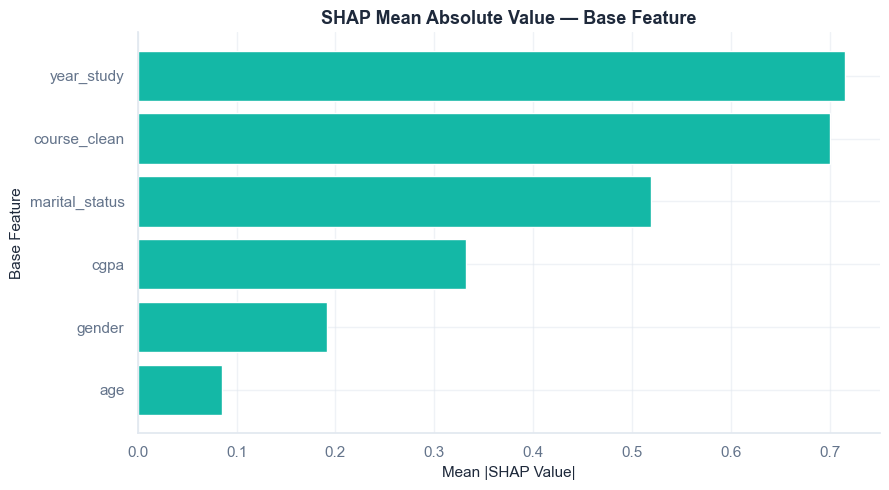

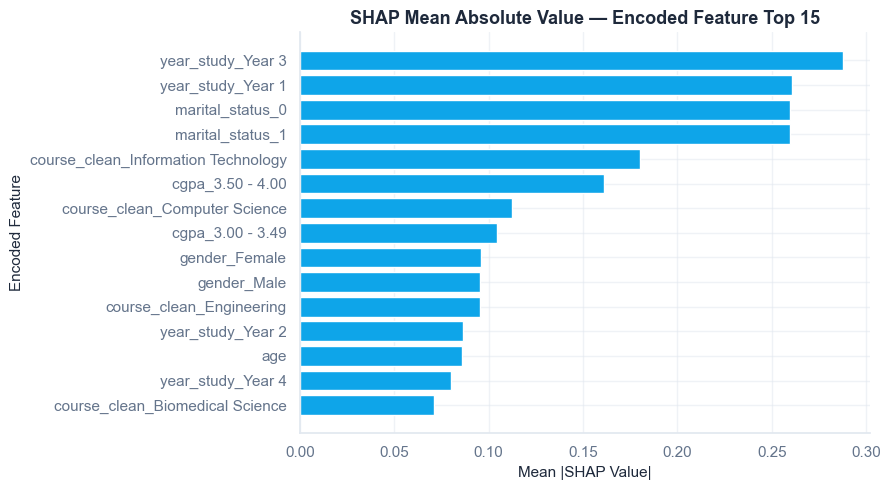

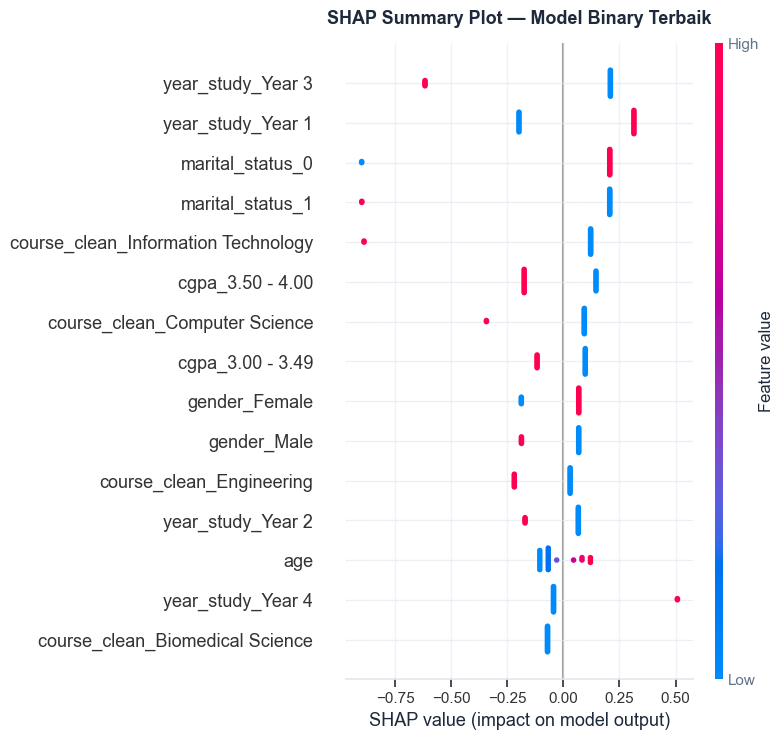

In [23]:
# SHAP Value untuk model binary terbaik.
# Kalau library SHAP belum tersedia di environment lokal, jalankan:
# %pip install shap

try:
    import shap
    HAS_SHAP = True
except Exception as e:
    HAS_SHAP = False
    print("Library SHAP belum tersedia. Install dulu dengan: %pip install shap")
    print("Detail:", e)

def ensure_dense_array(array_like):
    """Mengubah hasil transform preprocessing menjadi dense numpy array agar aman untuk SHAP."""
    if hasattr(array_like, "toarray"):
        return array_like.toarray()
    return np.asarray(array_like)

def normalize_shap_output(shap_values, model, positive_label="At Risk"):
    """
    Menormalkan output SHAP menjadi matriks 2D: [n_sample, n_feature].
    Untuk binary classifier, dipilih kelas positif 'At Risk' bila tersedia.
    """
    class_index = 0
    class_label = "model_output"

    if hasattr(model, "classes_"):
        classes = list(model.classes_)
        if positive_label in classes:
            class_index = classes.index(positive_label)
            class_label = str(positive_label)
        elif len(classes) > 1:
            class_index = 1
            class_label = str(classes[class_index])
        elif len(classes) == 1:
            class_label = str(classes[0])

    if isinstance(shap_values, list):
        if len(shap_values) > class_index:
            values_2d = shap_values[class_index]
        else:
            values_2d = shap_values[0]
    else:
        values = np.asarray(shap_values)
        if values.ndim == 3:
            # Umumnya shape SHAP tree sklearn: [n_sample, n_feature, n_class]
            if values.shape[2] > class_index:
                values_2d = values[:, :, class_index]
            else:
                values_2d = values[:, :, 0]
        else:
            values_2d = values

    return np.asarray(values_2d), class_label

shap_encoded_importance_df = pd.DataFrame(columns=[
    "encoded_feature", "mean_abs_shap", "mean_shap", "base_feature", "target_class", "model"
])
shap_base_importance_df = pd.DataFrame(columns=[
    "base_feature", "mean_abs_shap", "mean_shap", "target_class", "model"
])

if not HAS_SHAP:
    print("SHAP dilewati agar notebook tetap bisa dirun tanpa error.")
elif binary_holdout is None:
    print("SHAP dilewati karena binary_holdout tidak tersedia.")
else:
    best_binary_pipe = binary_holdout["pipeline"]
    shap_model = best_binary_pipe.named_steps["model"]
    shap_preprocessor = best_binary_pipe.named_steps["preprocess"]

    X_train_shap = binary_holdout["X_train"].copy()
    X_test_shap = binary_holdout["X_test"].copy()

    # Batasi jumlah sampel agar proses interpretasi tetap ringan dan stabil.
    background_size = min(100, len(X_train_shap))
    explain_size = min(200, len(X_test_shap))

    X_background_raw = X_train_shap.sample(
        n=background_size,
        random_state=RANDOM_STATE
    ) if background_size > 0 else X_train_shap

    X_explain_raw = X_test_shap.sample(
        n=explain_size,
        random_state=RANDOM_STATE
    ) if explain_size > 0 else X_test_shap

    feature_names = get_feature_names_from_pipeline(best_binary_pipe)

    X_background_transformed = ensure_dense_array(shap_preprocessor.transform(X_background_raw))
    X_explain_transformed = ensure_dense_array(shap_preprocessor.transform(X_explain_raw))

    # Jaga-jaga jika jumlah nama fitur dan kolom hasil preprocessing berbeda.
    if len(feature_names) != X_explain_transformed.shape[1]:
        feature_names = [f"feature_{i}" for i in range(X_explain_transformed.shape[1])]

    X_background_shap = pd.DataFrame(X_background_transformed, columns=feature_names)
    X_explain_shap = pd.DataFrame(X_explain_transformed, columns=feature_names)

    tree_models = (
        DecisionTreeClassifier,
        RandomForestClassifier,
        ExtraTreesClassifier,
        GradientBoostingClassifier,
    )

    try:
        if isinstance(shap_model, tree_models):
            explainer = shap.TreeExplainer(shap_model)
            raw_shap_values = explainer.shap_values(X_explain_shap)
        else:
            # Cocok untuk Logistic Regression dan model linear lain.
            explainer = shap.LinearExplainer(shap_model, X_background_shap)
            raw_shap_values = explainer.shap_values(X_explain_shap)

        shap_values_2d, shap_target_class = normalize_shap_output(
            raw_shap_values,
            shap_model,
            positive_label="At Risk"
        )

        if shap_values_2d.ndim != 2:
            raise ValueError(f"Output SHAP tidak berbentuk 2D. Shape: {shap_values_2d.shape}")

        shap_encoded_importance_df = pd.DataFrame({
            "encoded_feature": feature_names,
            "mean_abs_shap": np.abs(shap_values_2d).mean(axis=0),
            "mean_shap": shap_values_2d.mean(axis=0),
            "target_class": shap_target_class,
            "model": type(shap_model).__name__,
        })

        shap_encoded_importance_df["base_feature"] = shap_encoded_importance_df["encoded_feature"].apply(
            lambda x: map_base_feature(x, FEATURES)
        )

        shap_encoded_importance_df = shap_encoded_importance_df.sort_values(
            "mean_abs_shap",
            ascending=False
        ).reset_index(drop=True)

        shap_base_importance_df = (
            shap_encoded_importance_df
            .groupby(["base_feature", "target_class", "model"], as_index=False)
            .agg(
                mean_abs_shap=("mean_abs_shap", "sum"),
                mean_shap=("mean_shap", "sum"),
            )
            .sort_values("mean_abs_shap", ascending=False)
            .reset_index(drop=True)
        )

        display(Markdown(f"**Model yang dijelaskan:** `{type(shap_model).__name__}` untuk kelas `{shap_target_class}`"))
        display(shap_base_importance_df.round(5))
        display(shap_encoded_importance_df.head(20).round(5))

        if not shap_base_importance_df.empty:
            fig, ax = plt.subplots(figsize=(9, 5))
            plot_df = shap_base_importance_df.sort_values("mean_abs_shap", ascending=True)
            ax.barh(plot_df["base_feature"], plot_df["mean_abs_shap"], color=COLORS["teal"])
            ax.set_title("SHAP Mean Absolute Value — Base Feature")
            ax.set_xlabel("Mean |SHAP Value|")
            ax.set_ylabel("Base Feature")
            clean_axis(ax)
            save_viz("11_shap_base_feature_importance.png")

        if not shap_encoded_importance_df.empty:
            fig, ax = plt.subplots(figsize=(9, 5))
            plot_df = shap_encoded_importance_df.head(15).sort_values("mean_abs_shap", ascending=True)
            ax.barh(plot_df["encoded_feature"], plot_df["mean_abs_shap"], color=COLORS["cyan"])
            ax.set_title("SHAP Mean Absolute Value — Encoded Feature Top 15")
            ax.set_xlabel("Mean |SHAP Value|")
            ax.set_ylabel("Encoded Feature")
            clean_axis(ax)
            save_viz("12_shap_encoded_feature_importance_top15.png")

        # Beeswarm plot untuk melihat arah dan sebaran pengaruh fitur.
        # Dibuat pada fitur encoded agar sesuai dengan input aktual model setelah preprocessing.
        try:
            plt.figure(figsize=(10, 6))
            shap.summary_plot(
                shap_values_2d,
                X_explain_shap,
                max_display=15,
                show=False
            )
            plt.title("SHAP Summary Plot — Model Binary Terbaik", pad=14)
            plt.tight_layout()
            plt.savefig(
                VIZ_DIR / "13_shap_summary_plot_best_binary.png",
                dpi=220,
                bbox_inches="tight",
                facecolor="white"
            )
            plt.show()
        except Exception as e:
            print("SHAP summary plot dilewati:", e)

        shap_encoded_importance_df.to_csv(OUTPUT_DIR / "shap_encoded_importance_best_binary.csv", index=False)
        shap_base_importance_df.to_csv(OUTPUT_DIR / "shap_base_importance_best_binary.csv", index=False)

    except Exception as e:
        print("Perhitungan SHAP gagal, tetapi notebook tetap lanjut.")
        print("Detail:", type(e).__name__, e)


## 23. Export Output Modeling

In [24]:
all_valid_results_sorted.to_csv(OUTPUT_DIR / "model_improvement_experiments.csv", index=False)
result_leakage.to_csv(OUTPUT_DIR / "leakage_demo_results.csv", index=False)
valid_feature_importance_summary.to_csv(OUTPUT_DIR / "valid_feature_importance_summary.csv", index=False)
overall_valid_importance.to_csv(OUTPUT_DIR / "overall_valid_feature_importance.csv", index=False)
permutation_importance_df.to_csv(OUTPUT_DIR / "best_binary_permutation_importance.csv", index=False)
leak_feature_importance_summary.to_csv(OUTPUT_DIR / "leakage_feature_importance_summary.csv", index=False)
overall_leak_importance.to_csv(OUTPUT_DIR / "overall_leakage_feature_importance.csv", index=False)

print("Saved modeling outputs:")
for file in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", file)

all_valid_results_sorted.to_csv(OUTPUT_DIR / "model_improvement_experiments.csv", index=False)
result_leakage.to_csv(OUTPUT_DIR / "leakage_demo_results.csv", index=False)
valid_feature_importance_summary.to_csv(OUTPUT_DIR / "valid_feature_importance_summary.csv", index=False)
overall_valid_importance.to_csv(OUTPUT_DIR / "overall_valid_feature_importance.csv", index=False)
permutation_importance_df.to_csv(OUTPUT_DIR / "best_binary_permutation_importance.csv", index=False)
leak_feature_importance_summary.to_csv(OUTPUT_DIR / "leakage_feature_importance_summary.csv", index=False)
overall_leak_importance.to_csv(OUTPUT_DIR / "overall_leakage_feature_importance.csv", index=False)

# Export SHAP output bila cell SHAP sudah berhasil dijalankan.
if "shap_encoded_importance_df" in globals():
    shap_encoded_importance_df.to_csv(OUTPUT_DIR / "shap_encoded_importance_best_binary.csv", index=False)
if "shap_base_importance_df" in globals():
    shap_base_importance_df.to_csv(OUTPUT_DIR / "shap_base_importance_best_binary.csv", index=False)

print("Saved modeling outputs:")
for file in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", file)

Saved modeling outputs:
- d:\Github\nmitggsog-student-mental-health-analysis\prediction_pipeline_outputs\tables\age_summary.csv
- d:\Github\nmitggsog-student-mental-health-analysis\prediction_pipeline_outputs\tables\association_summary.csv
- d:\Github\nmitggsog-student-mental-health-analysis\prediction_pipeline_outputs\tables\best_binary_permutation_importance.csv
- d:\Github\nmitggsog-student-mental-health-analysis\prediction_pipeline_outputs\tables\cgpa_summary.csv
- d:\Github\nmitggsog-student-mental-health-analysis\prediction_pipeline_outputs\tables\combination_summary.csv
- d:\Github\nmitggsog-student-mental-health-analysis\prediction_pipeline_outputs\tables\course_issue_summary.csv
- d:\Github\nmitggsog-student-mental-health-analysis\prediction_pipeline_outputs\tables\feature_importance_support_status.csv
- d:\Github\nmitggsog-student-mental-health-analysis\prediction_pipeline_outputs\tables\gender_summary.csv
- d:\Github\nmitggsog-student-mental-health-analysis\prediction_pipeli

## 24. Final Takeaway

Notebook gabungan ini menunjukkan dua hal utama:

1. **EDA menjadi fondasi utama argumen**: masalah terbesar bukan hanya keberadaan indikator mental health, tetapi support gap pada kelompok yang sudah berindikasi.
2. **Modeling perlu dibaca hati-hati**: fitur demografis/survei dasar tidak otomatis cukup kuat untuk memprediksi kondisi mental health. Skor tinggi pada leakage demo tidak valid karena target pembentuk label ikut masuk sebagai fitur.

Karena itu, rekomendasi solusi yang paling aman adalah **dashboard monitoring agregat dan sistem dukungan awal yang etis**, bukan sistem diagnosis otomatis.

Tambahan interpretasi SHAP pada bagian akhir dipakai untuk membaca arah kontribusi fitur pada model terbaik, tetapi tetap tidak diposisikan sebagai bukti kausal.